In [ ]:
import numpy as np
from datetime import datetime
import datetime
from google.colab import drive
drive.mount('/content/drive')
from statsmodels.tsa import holtwinters as hw
import statsmodels.api as sm
import pandas as pd
import numpy as np
import plotly.express as px
import plotly
import plotly.graph_objs as go

FREQ = 'QS'

Mounted at /content/drive


/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
df = pd.read_csv('/content/drive/My Drive/Buchner/WI_H2_MFI_129921.csv')
df['date'] = pd.to_datetime(df['EPOCH_yyyy-mm-ddThh:mm:ss.sssZ'])
df = df.drop(['EPOCH_yyyy-mm-ddThh:mm:ss.sssZ'], axis=1)
df = df.set_index('date').resample('s').mean()
df2 = pd.read_csv('/content/drive/My Drive/Buchner/WI_H2_MFI_177920.csv')
df2['date'] = pd.to_datetime(df2['EPOCH_yyyy-mm-ddThh:mm:ss.sssZ'])
df2 = df2.set_index('date').resample('s').first()
df2 = df2.drop(['EPOCH_yyyy-mm-ddThh:mm:ss.sssZ'], axis=1)
df2.columns = ['bx', 'by', 'bz']
df = pd.concat([df, df2], axis=1)
df2 = pd.read_csv('/content/drive/My Drive/Buchner/WI_EM_3DP_129921.csv')
df2['date'] = pd.to_datetime(df2['EPOCH_yyyy-mm-ddThh:mm:ss.sssZ'])
df2 = df2.set_index('date').resample('s').first()
df2 = df2.drop(['EPOCH_yyyy-mm-ddThh:mm:ss.sssZ'], axis=1)
df2 = df2.fillna(method='pad', limit=2)
df2.columns = ['el_density', 'el_temp', 'vx', 'vy', 'vz']
df2['ve'] = (df2['vx'] ** 2 + df2['vy'] ** 2 + df2['vz'] ** 2) ** 0.5
df2 = df2.drop(['el_density', 'el_temp', 'vx', 'vy', 'vz'], axis=1)
df = pd.concat([df, df2], axis=1)
df2 = pd.read_csv('/content/drive/My Drive/Buchner/WI_PM_3DP_129921.csv')
df2['date'] = pd.to_datetime(df2['EPOCH_yyyy-mm-ddThh:mm:ss.sssZ'])
df2 = df2.set_index('date').resample('s').first()
df2 = df2.drop(['EPOCH_yyyy-mm-ddThh:mm:ss.sssZ'], axis=1)
df2 = df2.fillna(method='pad', limit=2)
df2.columns = ['density', 'temp', 'vx', 'vy', 'vz']
df2['vp'] = (df2['vx'] ** 2 + df2['vy'] ** 2 + df2['vz'] ** 2) ** 0.5
df2 = df2.drop(['vx', 'vy', 'vz'], axis=1)
df = pd.concat([df, df2], axis=1)
df = df[29:-2]
df['temp'] = df['temp'] * 11604.525
df['Beta'] = ((4.16 * 0.00001 * df['temp']) + 5.34) * df['density'] / np.square(df['B_nT'])
df['VA'] = 20 * df['B_nT'] / np.sqrt((df['density']))
df['B_der'] = np.insert(np.diff(df['B_nT']), 0, np.nan)
df['Beta_der'] = np.insert(np.diff(df['Beta']), 0, np.nan)
df['VA/V_der'] = np.insert(np.diff(df['VA'] / df['vp']), 0, np.nan)
df['vp/ve'] = df['vp'] / df['ve']
df['vp/ve_der'] = np.insert(np.diff(df['vp/ve']), 0, np.nan)
df['current_sheet'] = 0
df.loc[(df['B_der'] <= -0.14) & ((df['VA/V_der'] <= -0.003) | (df['Beta_der'] >= 0.11)), 'current_sheet'] = 1

In [ ]:
df2 = pd.read_csv('/content/drive/My Drive/Buchner/WI_EM_3DP_129921.csv')


In [ ]:
df

,B_nT,bx,by,bz,ve,density,temp,vp,Beta,VA,B_der,Beta_der,VA/V_der,vp/ve,vp/ve_der,current_sheet
date,,,,,,,,,,,,,,,,
1998-02-13 00:00:29+00:00,3.578843,3.56491,0.300034,0.175491,214.079672,4.53821,85908.994846,429.602413,3.158369,33.599309,NaN,NaN,NaN,2.006741,NaN,0
1998-02-13 00:00:30+00:00,3.566882,3.56516,0.217446,0.186372,214.079672,4.53821,85908.994846,429.602413,3.179587,33.487016,-0.011961,0.021218,-0.000261,2.006741,0.000000,0
1998-02-13 00:00:31+00:00,3.587292,3.55415,0.293670,0.179509,214.079672,4.53821,85908.994846,429.602413,3.143509,33.678629,0.020410,-0.036077,0.000446,2.006741,0.000000,0
1998-02-13 00:00:32+00:00,3.570658,3.57532,0.174054,0.177807,214.016175,4.36134,83852.092790,431.693177,3.019937,34.195448,-0.016634,-0.123572,0.000818,2.017105,0.010365,0
1998-02-13 00:00:33+00:00,3.555872,3.54752,0.292538,0.241719,214.016175,4.36134,83852.092790,431.693177,3.045105,34.053842,-0.014786,0.025168,-0.000328,2.017105,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1998-02-14 11:59:53+00:00,4.090575,3.74007,-1.541450,0.836652,223.142390,5.69614,58521.619575,354.215410,2.646577,34.278671,-0.027959,0.035811,-0.000661,1.587396,0.000000,0
1998-02-14 11:59:54+00:00,4.093611,3.71422,-1.478620,0.822361,227.608999,5.50771,56497.326234,354.154559,2.527555,34.885988,0.003036,-0.119022,0.001731,1.555978,-0.031418,0
1998-02-14 11:59:55+00:00,4.083315,3.72809,-1.485490,0.747380,227.608999,5.50771,56497.326234,354.154559,2.540318,34.798242,-0.010296,0.012763,-0.000248,1.555978,0.000000,0


In [ ]:
df2 = pd.read_csv('/content/drive/My Drive/Buchner/WI_PM_3DP_129921.csv')
df2.columns = ['date', 'density', 'temp', 'vx', 'vy', 'vz']
df2['vp'] = (df2['vx'] ** 2 + df2['vy'] ** 2 + df2['vz'] ** 2) ** 0.5
df2

,date,density,temp,vx,vy,vz,vp
0,1998-02-13T00:00:05.494Z,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-02-13T00:00:08.496Z,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-02-13T00:00:14.500Z,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-02-13T00:00:17.501Z,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-02-13T00:00:23.505Z,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
42907,1998-02-14T11:59:45.159Z,5.31369,4.91887,-353.776,16.9284,4.95257,354.215410
42908,1998-02-14T11:59:48.161Z,5.28480,5.12314,-355.572,16.0192,3.98107,355.954928
42909,1998-02-14T11:59:51.163Z,5.69614,5.04300,-353.776,16.9284,4.95257,354.215410
42910,1998-02-14T11:59:54.165Z,5.50771,4.86856,-353.679,17.9142,3.96205,354.154559


In [ ]:
df2

,date,density,temp,vx,vy,vz,vp
0,1998-02-13T00:00:05.494Z,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-02-13T00:00:08.496Z,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-02-13T00:00:14.500Z,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-02-13T00:00:17.501Z,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-02-13T00:00:23.505Z,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
42907,1998-02-14T11:59:45.159Z,5.31369,4.91887,-353.776,16.9284,4.95257,354.215410
42908,1998-02-14T11:59:48.161Z,5.28480,5.12314,-355.572,16.0192,3.98107,355.954928
42909,1998-02-14T11:59:51.163Z,5.69614,5.04300,-353.776,16.9284,4.95257,354.215410
42910,1998-02-14T11:59:54.165Z,5.50771,4.86856,-353.679,17.9142,3.96205,354.154559


In [ ]:
df['ve/vp'] = df['ve'] / df['vp']
df['ve/vp_der'] = np.insert(np.diff(df['ve/vp']), 0, np.nan)

In [ ]:
df['ve_der/vp_der'] = abs(np.insert(np.diff(df['ve']), 0, np.nan) / np.insert(np.diff(df['vp']), 0, np.nan))
df['ve_der/vp_der'][df['ve_der/vp_der'] > 100] = 0

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in true_divide
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [ ]:
np.mean(df['ve_der/vp_der'])

9.260182339207095

In [ ]:
df['ve_der/vp_der']

date
1998-02-13 00:00:29+00:00          NaN
1998-02-13 00:00:30+00:00          NaN
1998-02-13 00:00:31+00:00          NaN
1998-02-13 00:00:32+00:00     0.030370
1998-02-13 00:00:33+00:00          NaN
                               ...    
1998-02-14 11:59:53+00:00          NaN
1998-02-14 11:59:54+00:00    73.401728
1998-02-14 11:59:55+00:00          NaN
1998-02-14 11:59:56+00:00          NaN
1998-02-14 11:59:57+00:00     0.000000
Freq: S, Name: ve_der/vp_der, Length: 129569, dtype: float64

In [ ]:
df['VA/V'] = df['VA'] / df['vp']

In [ ]:
df

,B_nT,bx,by,bz,ve,density,temp,vp,Beta,VA,B_der,Beta_der,VA/V_der,vp/ve,vp/ve_der,current_sheet,ve/vp,ve/vp_der,ve_der/vp_der,VA/V
date,,,,,,,,,,,,,,,,,,,,
1998-02-13 00:00:29+00:00,3.578843,3.56491,0.300034,0.175491,214.079672,4.53821,85908.994846,429.602413,3.158369,33.599309,NaN,NaN,NaN,2.006741,NaN,0,0.498320,NaN,NaN,0.078210
1998-02-13 00:00:30+00:00,3.566882,3.56516,0.217446,0.186372,214.079672,4.53821,85908.994846,429.602413,3.179587,33.487016,-0.011961,0.021218,-0.000261,2.006741,0.000000,0,0.498320,0.000000,NaN,0.077949
1998-02-13 00:00:31+00:00,3.587292,3.55415,0.293670,0.179509,214.079672,4.53821,85908.994846,429.602413,3.143509,33.678629,0.020410,-0.036077,0.000446,2.006741,0.000000,0,0.498320,0.000000,NaN,0.078395
1998-02-13 00:00:32+00:00,3.570658,3.57532,0.174054,0.177807,214.016175,4.36134,83852.092790,431.693177,3.019937,34.195448,-0.016634,-0.123572,0.000818,2.017105,0.010365,0,0.495760,-0.002561,0.030370,0.079212
1998-02-13 00:00:33+00:00,3.555872,3.54752,0.292538,0.241719,214.016175,4.36134,83852.092790,431.693177,3.045105,34.053842,-0.014786,0.025168,-0.000328,2.017105,0.000000,0,0.495760,0.000000,NaN,0.078884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1998-02-14 11:59:53+00:00,4.090575,3.74007,-1.541450,0.836652,223.142390,5.69614,58521.619575,354.215410,2.646577,34.278671,-0.027959,0.035811,-0.000661,1.587396,0.000000,0,0.629962,0.000000,NaN,0.096774
1998-02-14 11:59:54+00:00,4.093611,3.71422,-1.478620,0.822361,227.608999,5.50771,56497.326234,354.154559,2.527555,34.885988,0.003036,-0.119022,0.001731,1.555978,-0.031418,0,0.642683,0.012720,73.401728,0.098505
1998-02-14 11:59:55+00:00,4.083315,3.72809,-1.485490,0.747380,227.608999,5.50771,56497.326234,354.154559,2.540318,34.798242,-0.010296,0.012763,-0.000248,1.555978,0.000000,0,0.642683,0.000000,NaN,0.098257


In [ ]:
df[['current_sheet', 'vp/ve','vp/ve_der']].to_csv('/content/drive/My Drive/Buchner/current_sheets_and_speed_ratio.csv')

In [ ]:
df

,B_nT,bx,by,bz,ve,density,temp,vp,Beta,VA,B_der,Beta_der,VA/V_der,vp/ve,vp/ve_der,current_sheet,ve/vp,ve/vp_der,ve_der/vp_der,VA/V
date,,,,,,,,,,,,,,,,,,,,
1998-02-13 00:00:29+00:00,3.578843,3.56491,0.300034,0.175491,214.079672,4.53821,85908.994846,429.602413,3.158369,33.599309,NaN,NaN,NaN,2.006741,NaN,0,0.498320,NaN,NaN,0.078210
1998-02-13 00:00:30+00:00,3.566882,3.56516,0.217446,0.186372,214.079672,4.53821,85908.994846,429.602413,3.179587,33.487016,-0.011961,0.021218,-0.000261,2.006741,0.000000,0,0.498320,0.000000,NaN,0.077949
1998-02-13 00:00:31+00:00,3.587292,3.55415,0.293670,0.179509,214.079672,4.53821,85908.994846,429.602413,3.143509,33.678629,0.020410,-0.036077,0.000446,2.006741,0.000000,0,0.498320,0.000000,NaN,0.078395
1998-02-13 00:00:32+00:00,3.570658,3.57532,0.174054,0.177807,214.016175,4.36134,83852.092790,431.693177,3.019937,34.195448,-0.016634,-0.123572,0.000818,2.017105,0.010365,0,0.495760,-0.002561,0.030370,0.079212
1998-02-13 00:00:33+00:00,3.555872,3.54752,0.292538,0.241719,214.016175,4.36134,83852.092790,431.693177,3.045105,34.053842,-0.014786,0.025168,-0.000328,2.017105,0.000000,0,0.495760,0.000000,NaN,0.078884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1998-02-14 11:59:53+00:00,4.090575,3.74007,-1.541450,0.836652,223.142390,5.69614,58521.619575,354.215410,2.646577,34.278671,-0.027959,0.035811,-0.000661,1.587396,0.000000,0,0.629962,0.000000,NaN,0.096774
1998-02-14 11:59:54+00:00,4.093611,3.71422,-1.478620,0.822361,227.608999,5.50771,56497.326234,354.154559,2.527555,34.885988,0.003036,-0.119022,0.001731,1.555978,-0.031418,0,0.642683,0.012720,73.401728,0.098505
1998-02-14 11:59:55+00:00,4.083315,3.72809,-1.485490,0.747380,227.608999,5.50771,56497.326234,354.154559,2.540318,34.798242,-0.010296,0.012763,-0.000248,1.555978,0.000000,0,0.642683,0.000000,NaN,0.098257


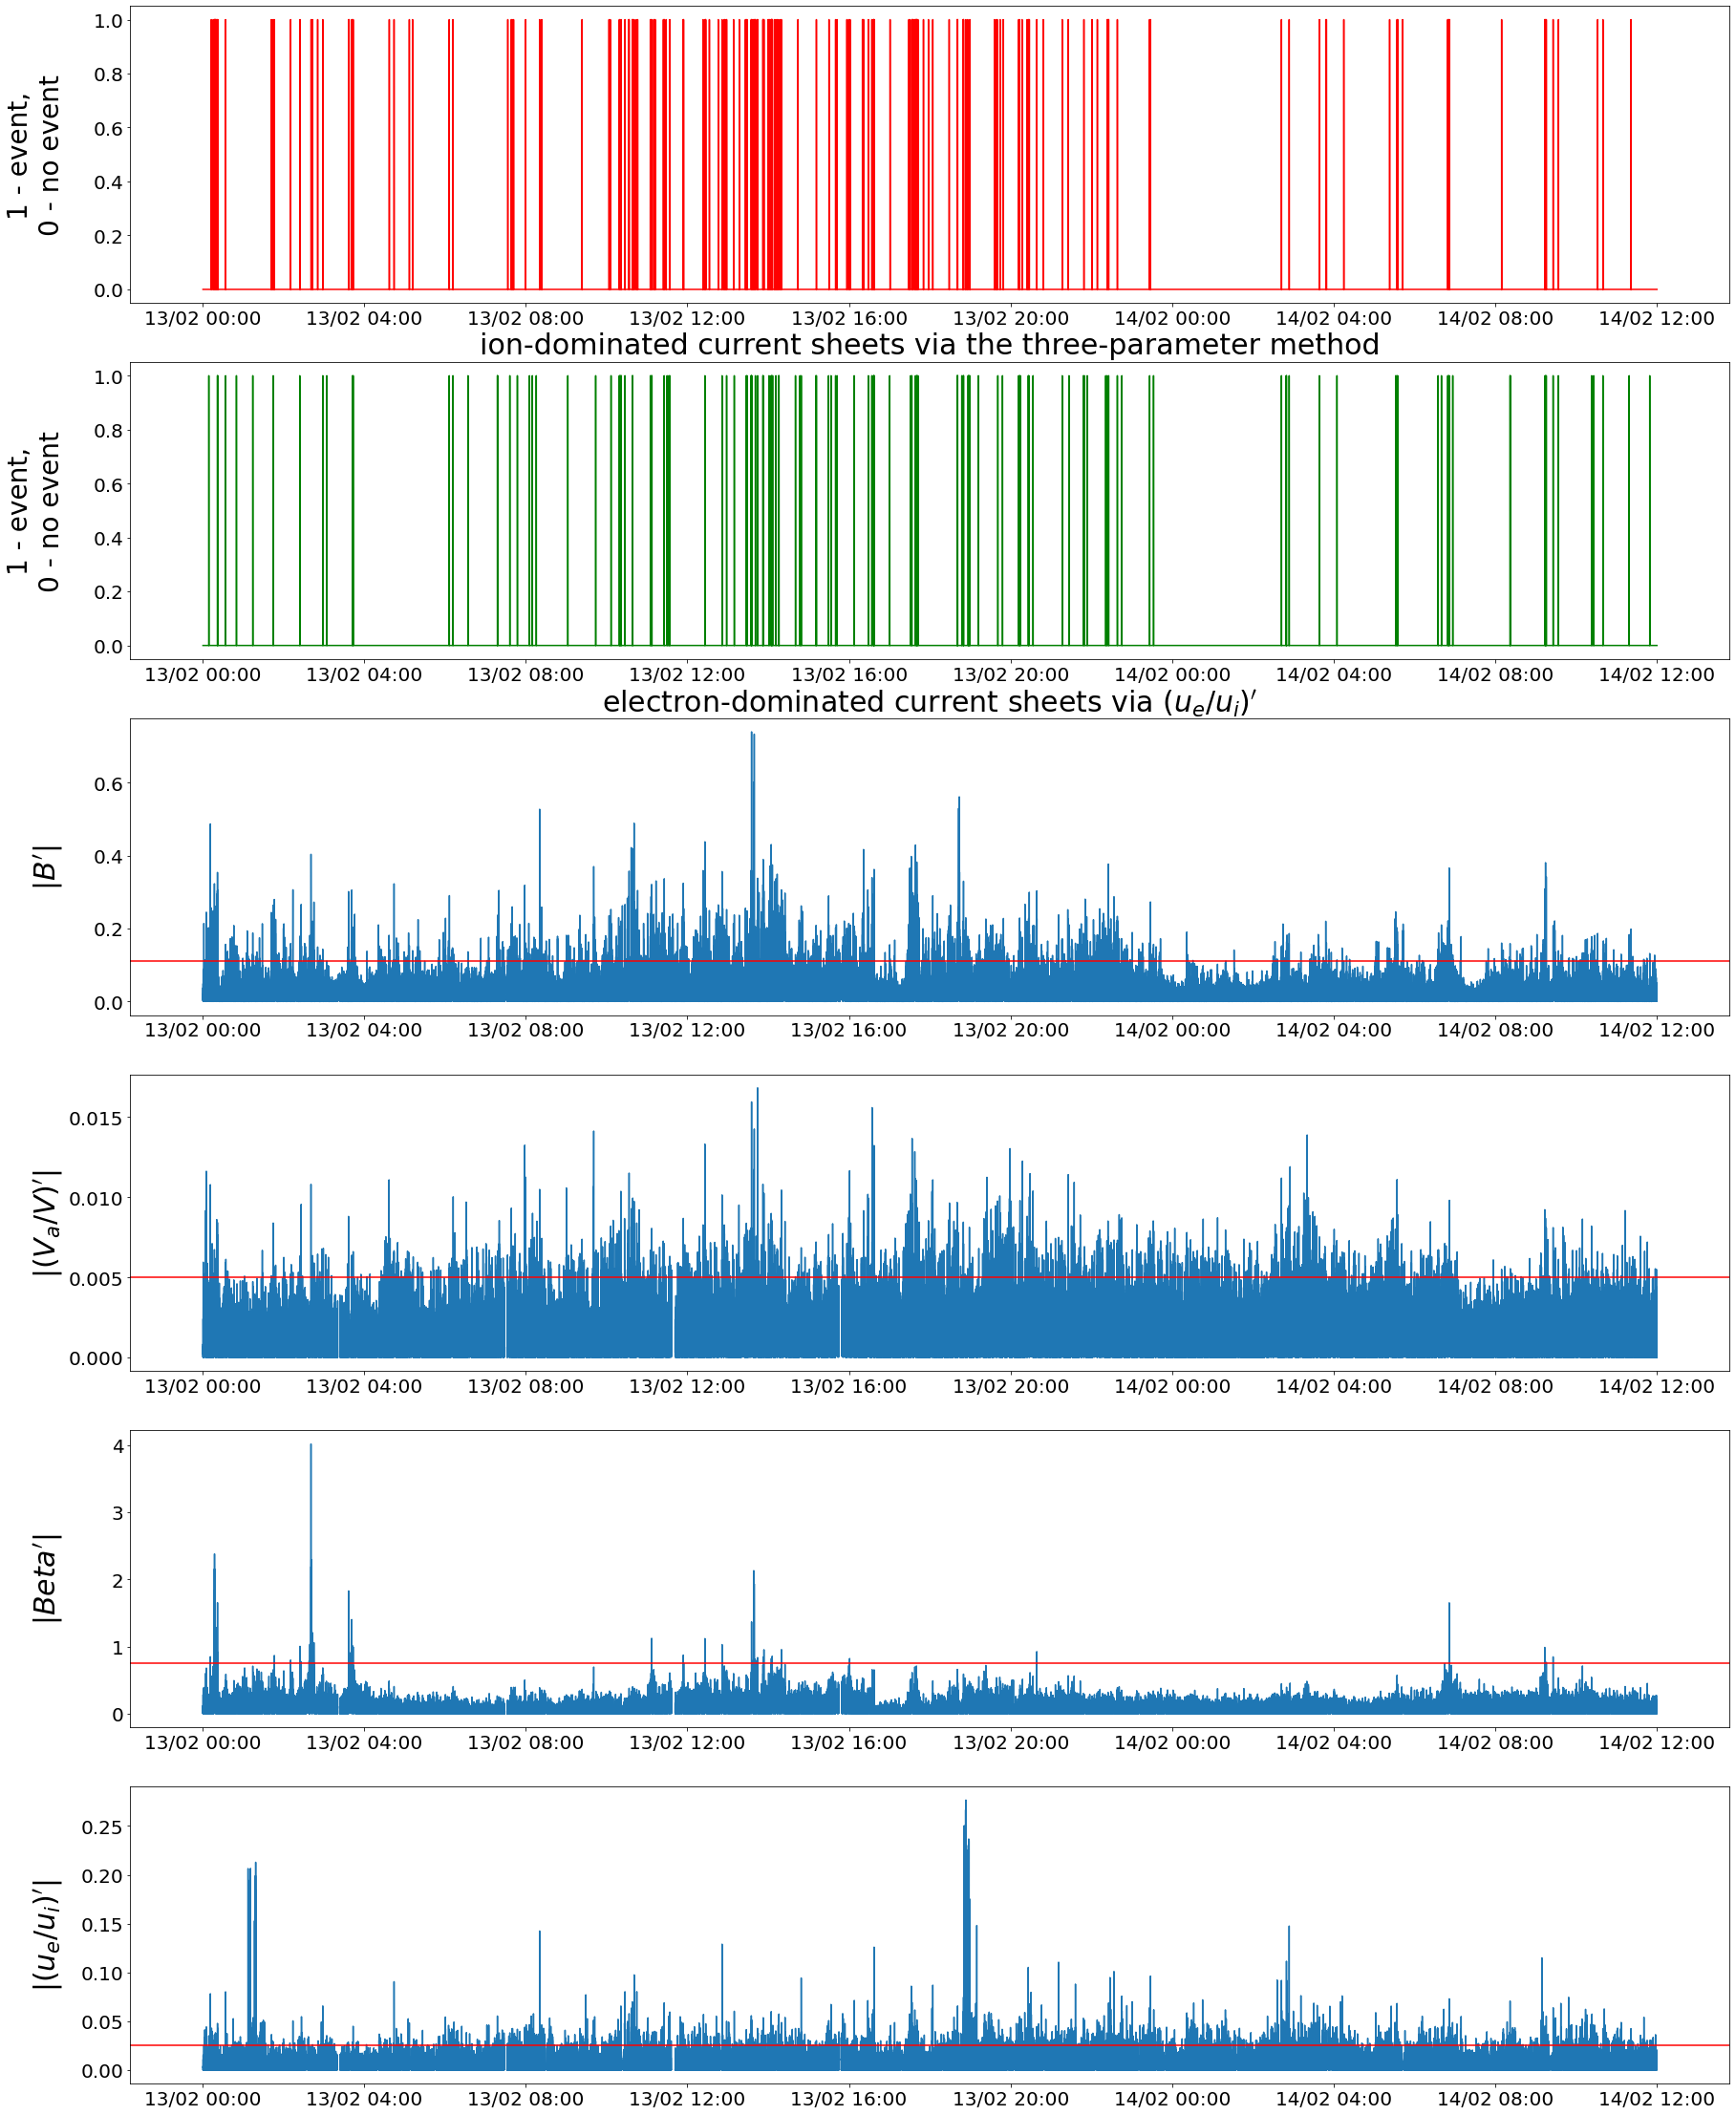

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams.update({'font.size': 20})
fig = plt.figure(1, figsize=(30,40))
ax1 = plt.subplot(611)
ax2 = plt.subplot(612)
ax1.plot(df['current_sheet_v2'], 'r')
ax2.plot(df['current_sheet_buchner_v2'], 'g')
ax3 = plt.subplot(613)
ax4 = plt.subplot(614)
ax3.plot(df['B_der'].abs())
ax4.plot(df['VA/V_der'].abs())
ax5 = plt.subplot(615)
ax5.plot(df['Beta_der'].abs())
ax6 = plt.subplot(616)
ax6.plot(df['ve/vp_der'].abs())
ax2.set_xlabel("electron-dominated current sheets via $(u_e/u_i)'$", fontsize=30)
ax1.set_ylabel('1 - event,\n0 - no event', fontsize=28)
ax2.set_ylabel('1 - event,\n0 - no event', fontsize=28)
ax1.set_xlabel('ion-dominated current sheets via the three-parameter method', fontsize=30)
ax3.set_ylabel("$|B'|$", fontsize=30)
ax4.set_ylabel("$|(V_a/V)'|$", fontsize=30)
ax5.set_ylabel("$|Beta'|$", fontsize=30)
ax6.set_ylabel("$|(u_e/u_i)'|$", fontsize=30)
myFmt = mdates.DateFormatter('%d/%m %H:%M')
ax1.xaxis.set_major_formatter(myFmt)
ax2.xaxis.set_major_formatter(myFmt)
ax3.xaxis.set_major_formatter(myFmt)
ax4.xaxis.set_major_formatter(myFmt)
ax5.xaxis.set_major_formatter(myFmt)
ax6.xaxis.set_major_formatter(myFmt)
ax3.axhline(y=0.11, color ='r')
ax4.axhline(y=0.005, color ='r')
ax5.axhline(y=0.75, color ='r')
ax6.axhline(y=0.025, color ='r')
fig.align_ylabels()
plt.savefig('buchner_11.jpeg',bbox_inches='tight')
plt.show()

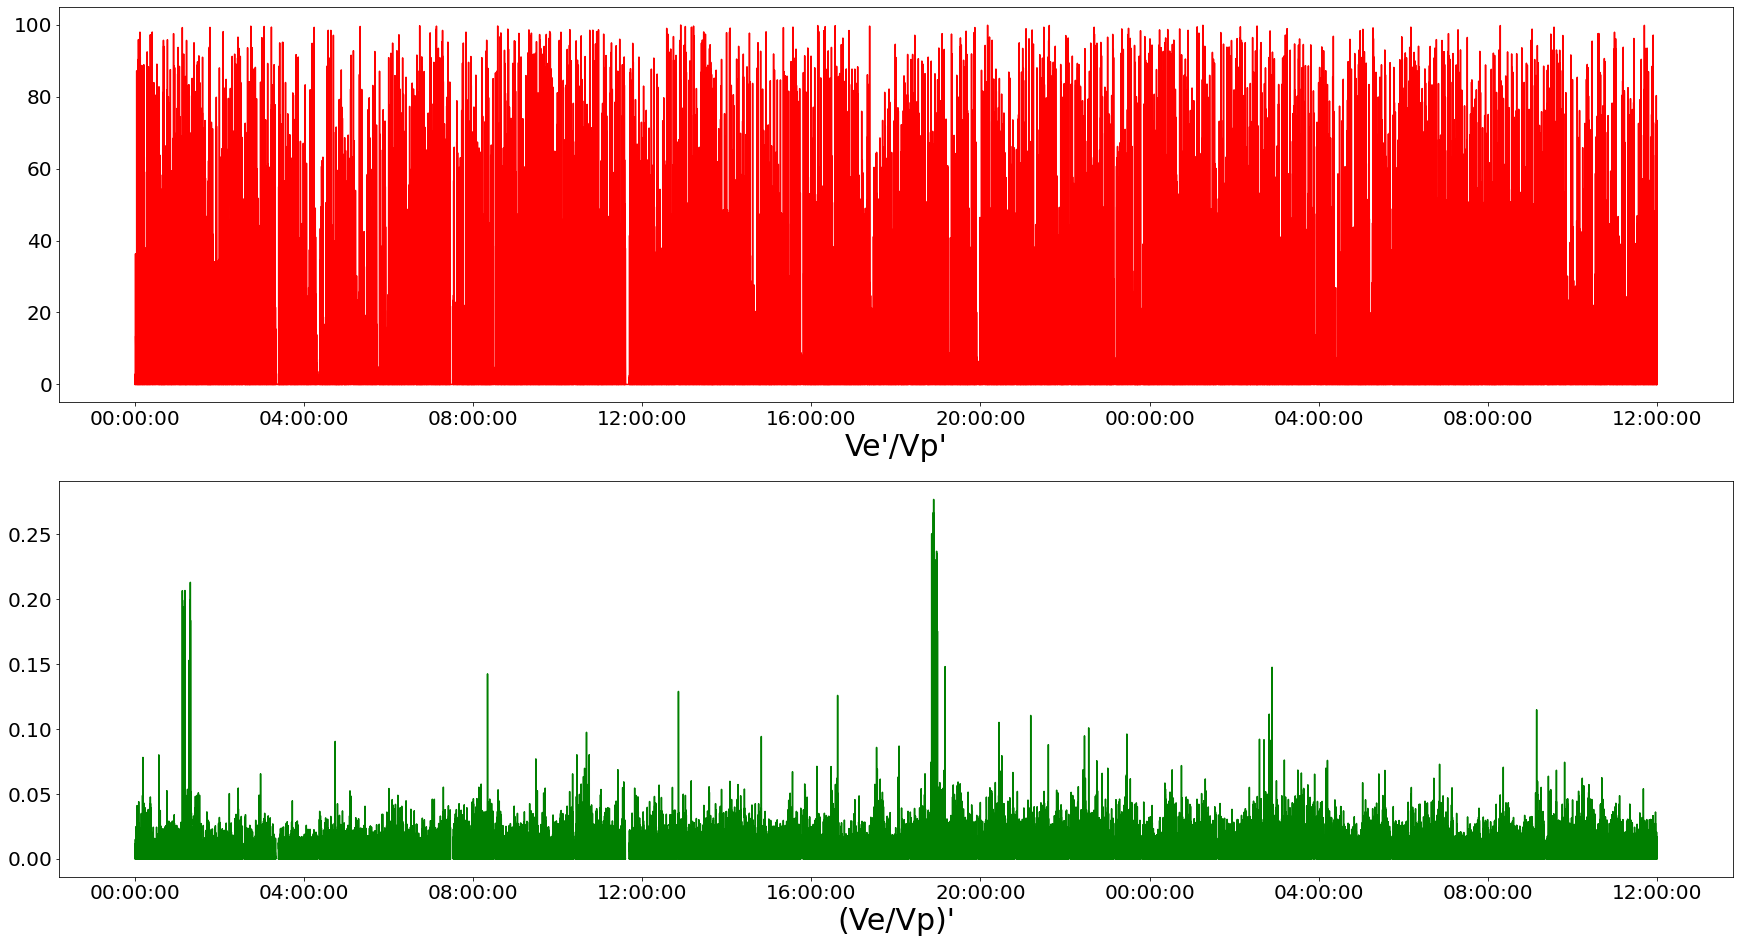

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
fig = plt.figure(1, figsize=(30,16))
ax1 = plt.subplot(211)
ax2 = plt.subplot(212)
ax2.plot(abs(df['ve/vp_der']), 'g')
ax1.plot(df['ve_der/vp_der'].fillna(0), 'r')
myFmt = mdates.DateFormatter('%H:%M:00')
ax1.xaxis.set_major_formatter(myFmt)
ax2.xaxis.set_major_formatter(myFmt)
ax2.set_xlabel("(Ve/Vp)'", fontsize=30)
ax1.set_xlabel("Ve'/Vp'", fontsize=30)
plt.show()

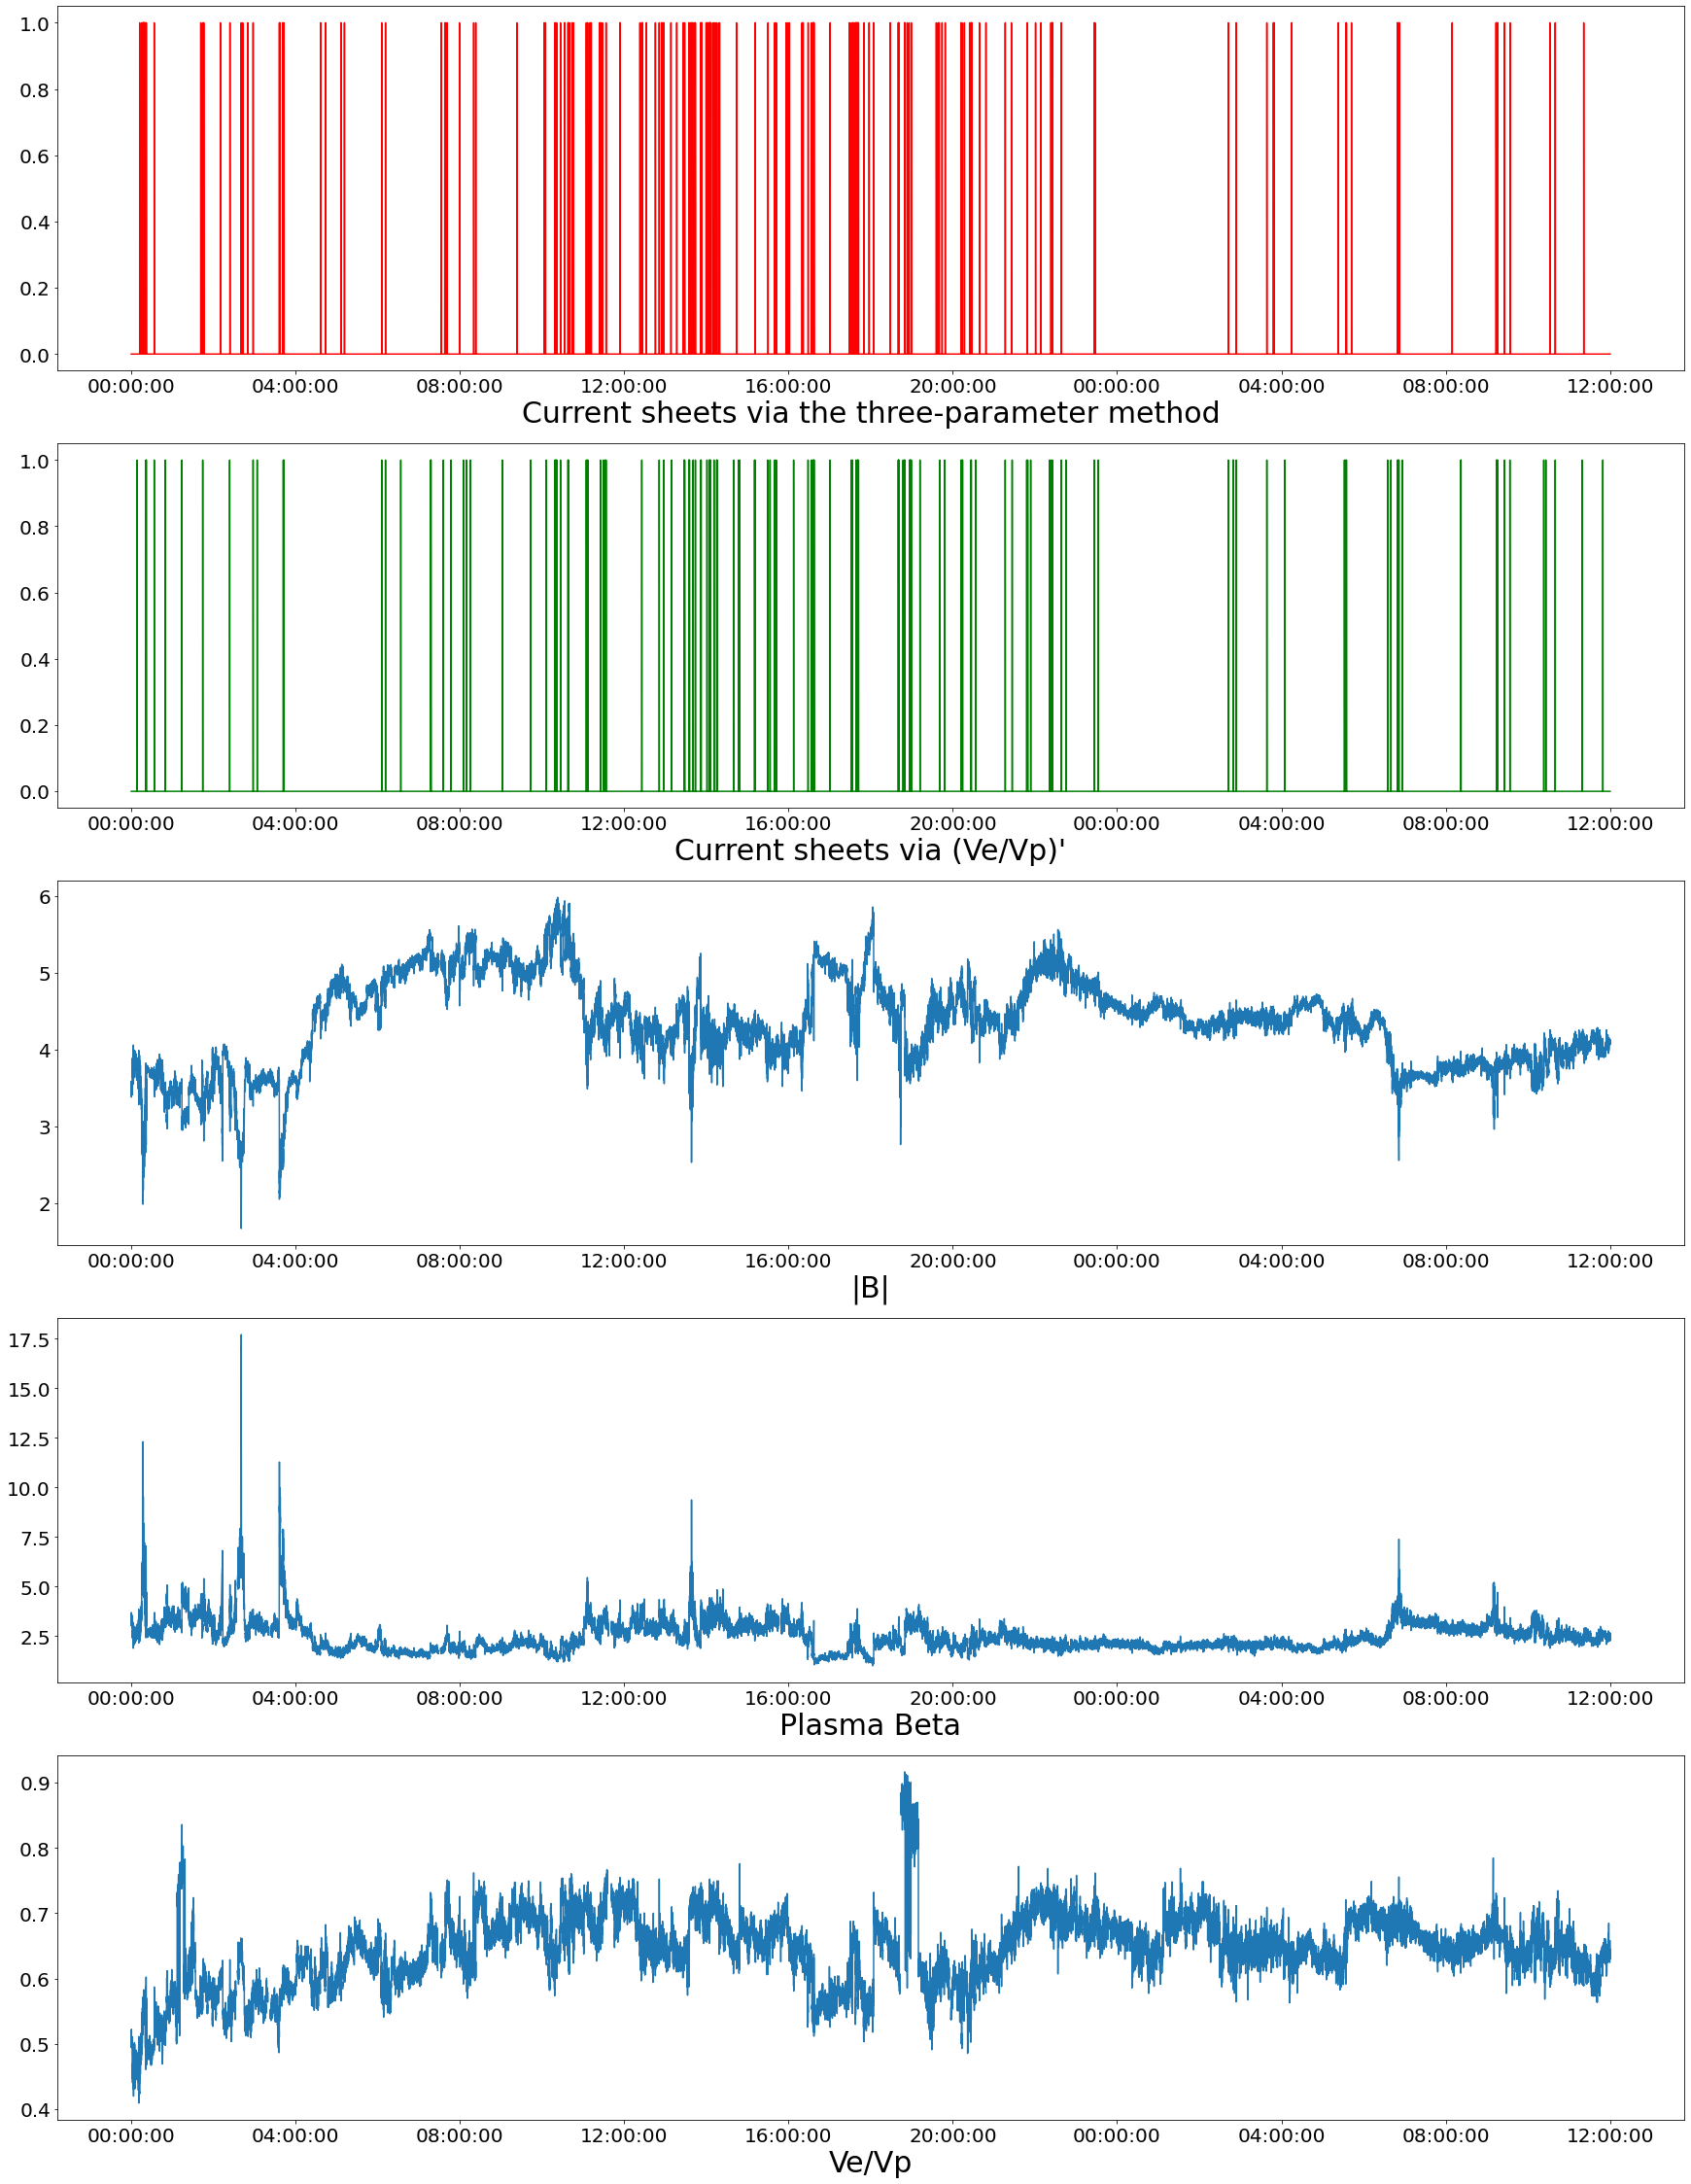

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
fig = plt.figure(1, figsize=(30,40))
ax1 = plt.subplot(511)
ax2 = plt.subplot(512)
ax2.plot(df['current_sheet_buchner_v2'], 'g')
ax1.plot(df['current_sheet_v2'], 'r')
ax3 = plt.subplot(513)
ax3.plot(df['B_nT'])
ax4 = plt.subplot(514)
ax4.plot(df['Beta'])
ax5 = plt.subplot(515)
ax5.plot(df['ve/vp'])
ax2.set_xlabel("Current sheets via (Ve/Vp)'", fontsize=30)
ax1.set_xlabel('Current sheets via the three-parameter method', fontsize=30)
ax3.set_xlabel('|B|', fontsize=30)
ax4.set_xlabel('Plasma Beta', fontsize=30)
ax5.set_xlabel('Ve/Vp', fontsize=30)
myFmt = mdates.DateFormatter('%H:%M:00')
ax1.xaxis.set_major_formatter(myFmt)
ax2.xaxis.set_major_formatter(myFmt)
ax3.xaxis.set_major_formatter(myFmt)
ax4.xaxis.set_major_formatter(myFmt)
ax5.xaxis.set_major_formatter(myFmt)
plt.show()

In [ ]:
df

,B_nT,ve,density,temp,vp,Beta,VA,B_der,Beta_der,VA/V_der,vp/ve,vp/ve_der,current_sheet,ve/vp,ve/vp_der,VA/V,current_sheet_v2,current_sheet_buchner,current_sheet_buchner_v2
date,,,,,,,,,,,,,,,,,,,
1998-02-13 00:00:29+00:00,3.578843,214.079672,4.53821,85908.994847,429.602413,3.158369,33.599309,NaN,NaN,NaN,2.006741,NaN,0,0.498320,NaN,0.078210,0,0,0
1998-02-13 00:00:30+00:00,3.566882,214.079672,4.53821,85908.994847,429.602413,3.179587,33.487016,-0.011961,0.021218,-0.000261,2.006741,0.000000,0,0.498320,0.000000,0.077949,0,0,0
1998-02-13 00:00:31+00:00,3.587292,214.079672,4.53821,85908.994847,429.602413,3.143509,33.678629,0.020410,-0.036077,0.000446,2.006741,0.000000,0,0.498320,0.000000,0.078395,0,0,0
1998-02-13 00:00:32+00:00,3.570658,214.016175,4.36134,83852.092790,431.693177,3.019937,34.195448,-0.016634,-0.123572,0.000818,2.017105,0.010365,0,0.495760,-0.002561,0.079212,0,0,0
1998-02-13 00:00:33+00:00,3.555872,214.016175,4.36134,83852.092790,431.693177,3.045105,34.053842,-0.014786,0.025168,-0.000328,2.017105,0.000000,0,0.495760,0.000000,0.078884,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1998-02-14 11:59:53+00:00,4.090575,223.142390,5.69614,58521.619575,354.215410,2.646577,34.278671,-0.027959,0.035811,-0.000661,1.587396,0.000000,0,0.629962,0.000000,0.096774,0,0,0
1998-02-14 11:59:54+00:00,4.093611,227.608999,5.50771,56497.326234,354.154559,2.527555,34.885988,0.003036,-0.119022,0.001731,1.555978,-0.031418,0,0.642683,0.012720,0.098505,0,0,0
1998-02-14 11:59:55+00:00,4.083315,227.608999,5.50771,56497.326234,354.154559,2.540318,34.798242,-0.010296,0.012763,-0.000248,1.555978,0.000000,0,0.642683,0.000000,0.098257,0,0,0


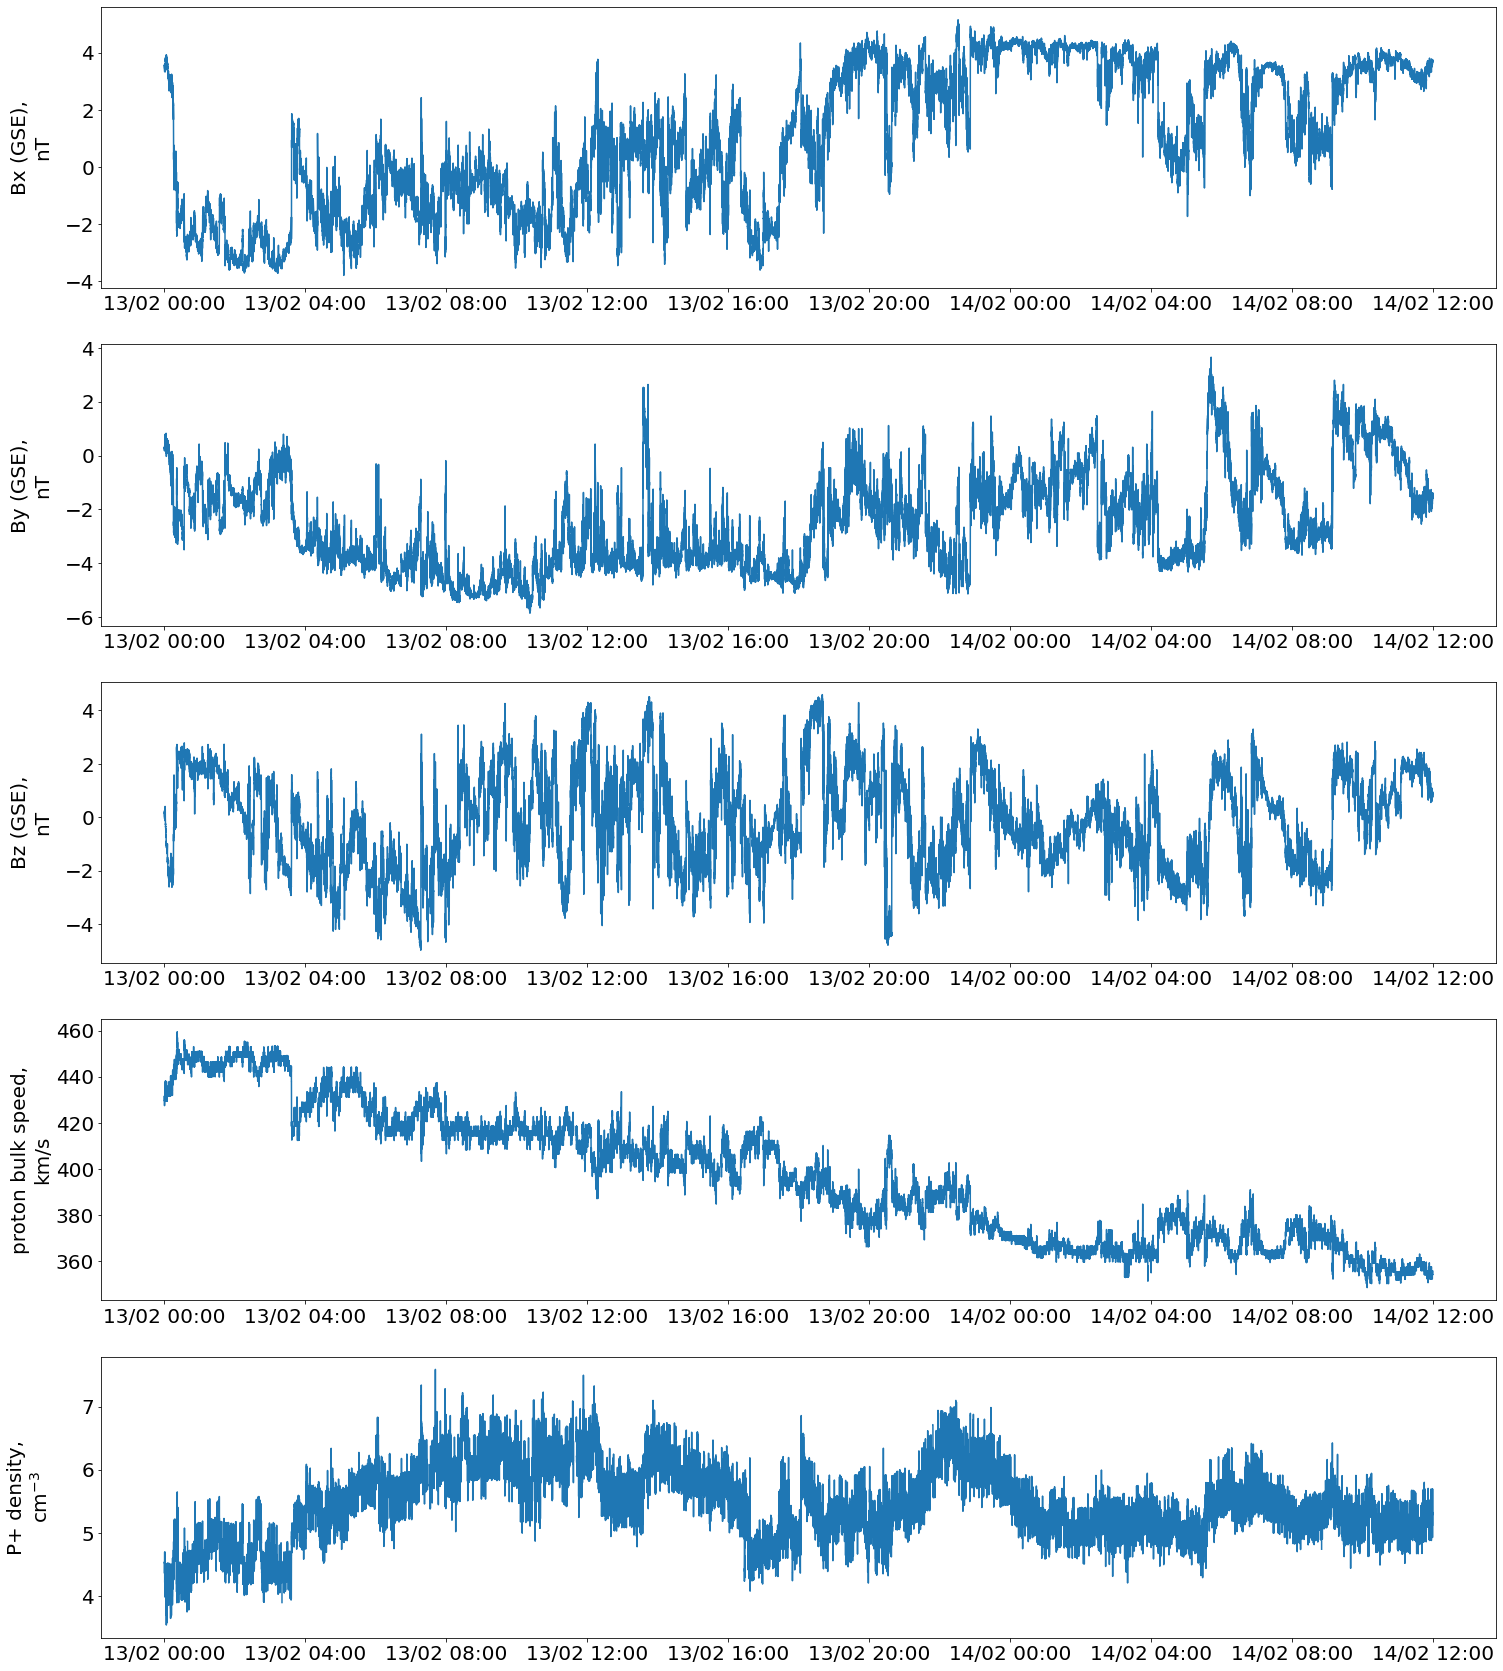

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
fig = plt.figure(1, figsize=(25,30))

ax1 = plt.subplot(511)
ax2 = plt.subplot(512)
ax3 = plt.subplot(513)
ax4 = plt.subplot(514)
ax5 = plt.subplot(515)

ax1.plot(df['bx'])
ax2.plot(df['by'])
ax3.plot(df['bz'])
ax4.plot(df['vp'])
ax5.plot(df['density'])

ax1.set_ylabel('Bx (GSE),\nnT',            fontsize=20)
ax2.set_ylabel('By (GSE),\nnT',            fontsize=20)
ax3.set_ylabel('Bz (GSE),\nnT',            fontsize=20)
ax4.set_ylabel('proton bulk speed,\nkm/s', fontsize=20)
ax5.set_ylabel('P+ density,\ncm$^{-3}$',   fontsize=20)

myFmt = mdates.DateFormatter('%d/%m %H:%M')
ax1.xaxis.set_major_formatter(myFmt)
ax2.xaxis.set_major_formatter(myFmt)
ax3.xaxis.set_major_formatter(myFmt)
ax4.xaxis.set_major_formatter(myFmt)
ax5.xaxis.set_major_formatter(myFmt)
fig.align_ylabels()
plt.savefig('buchner_9.jpeg',bbox_inches='tight')
plt.show()

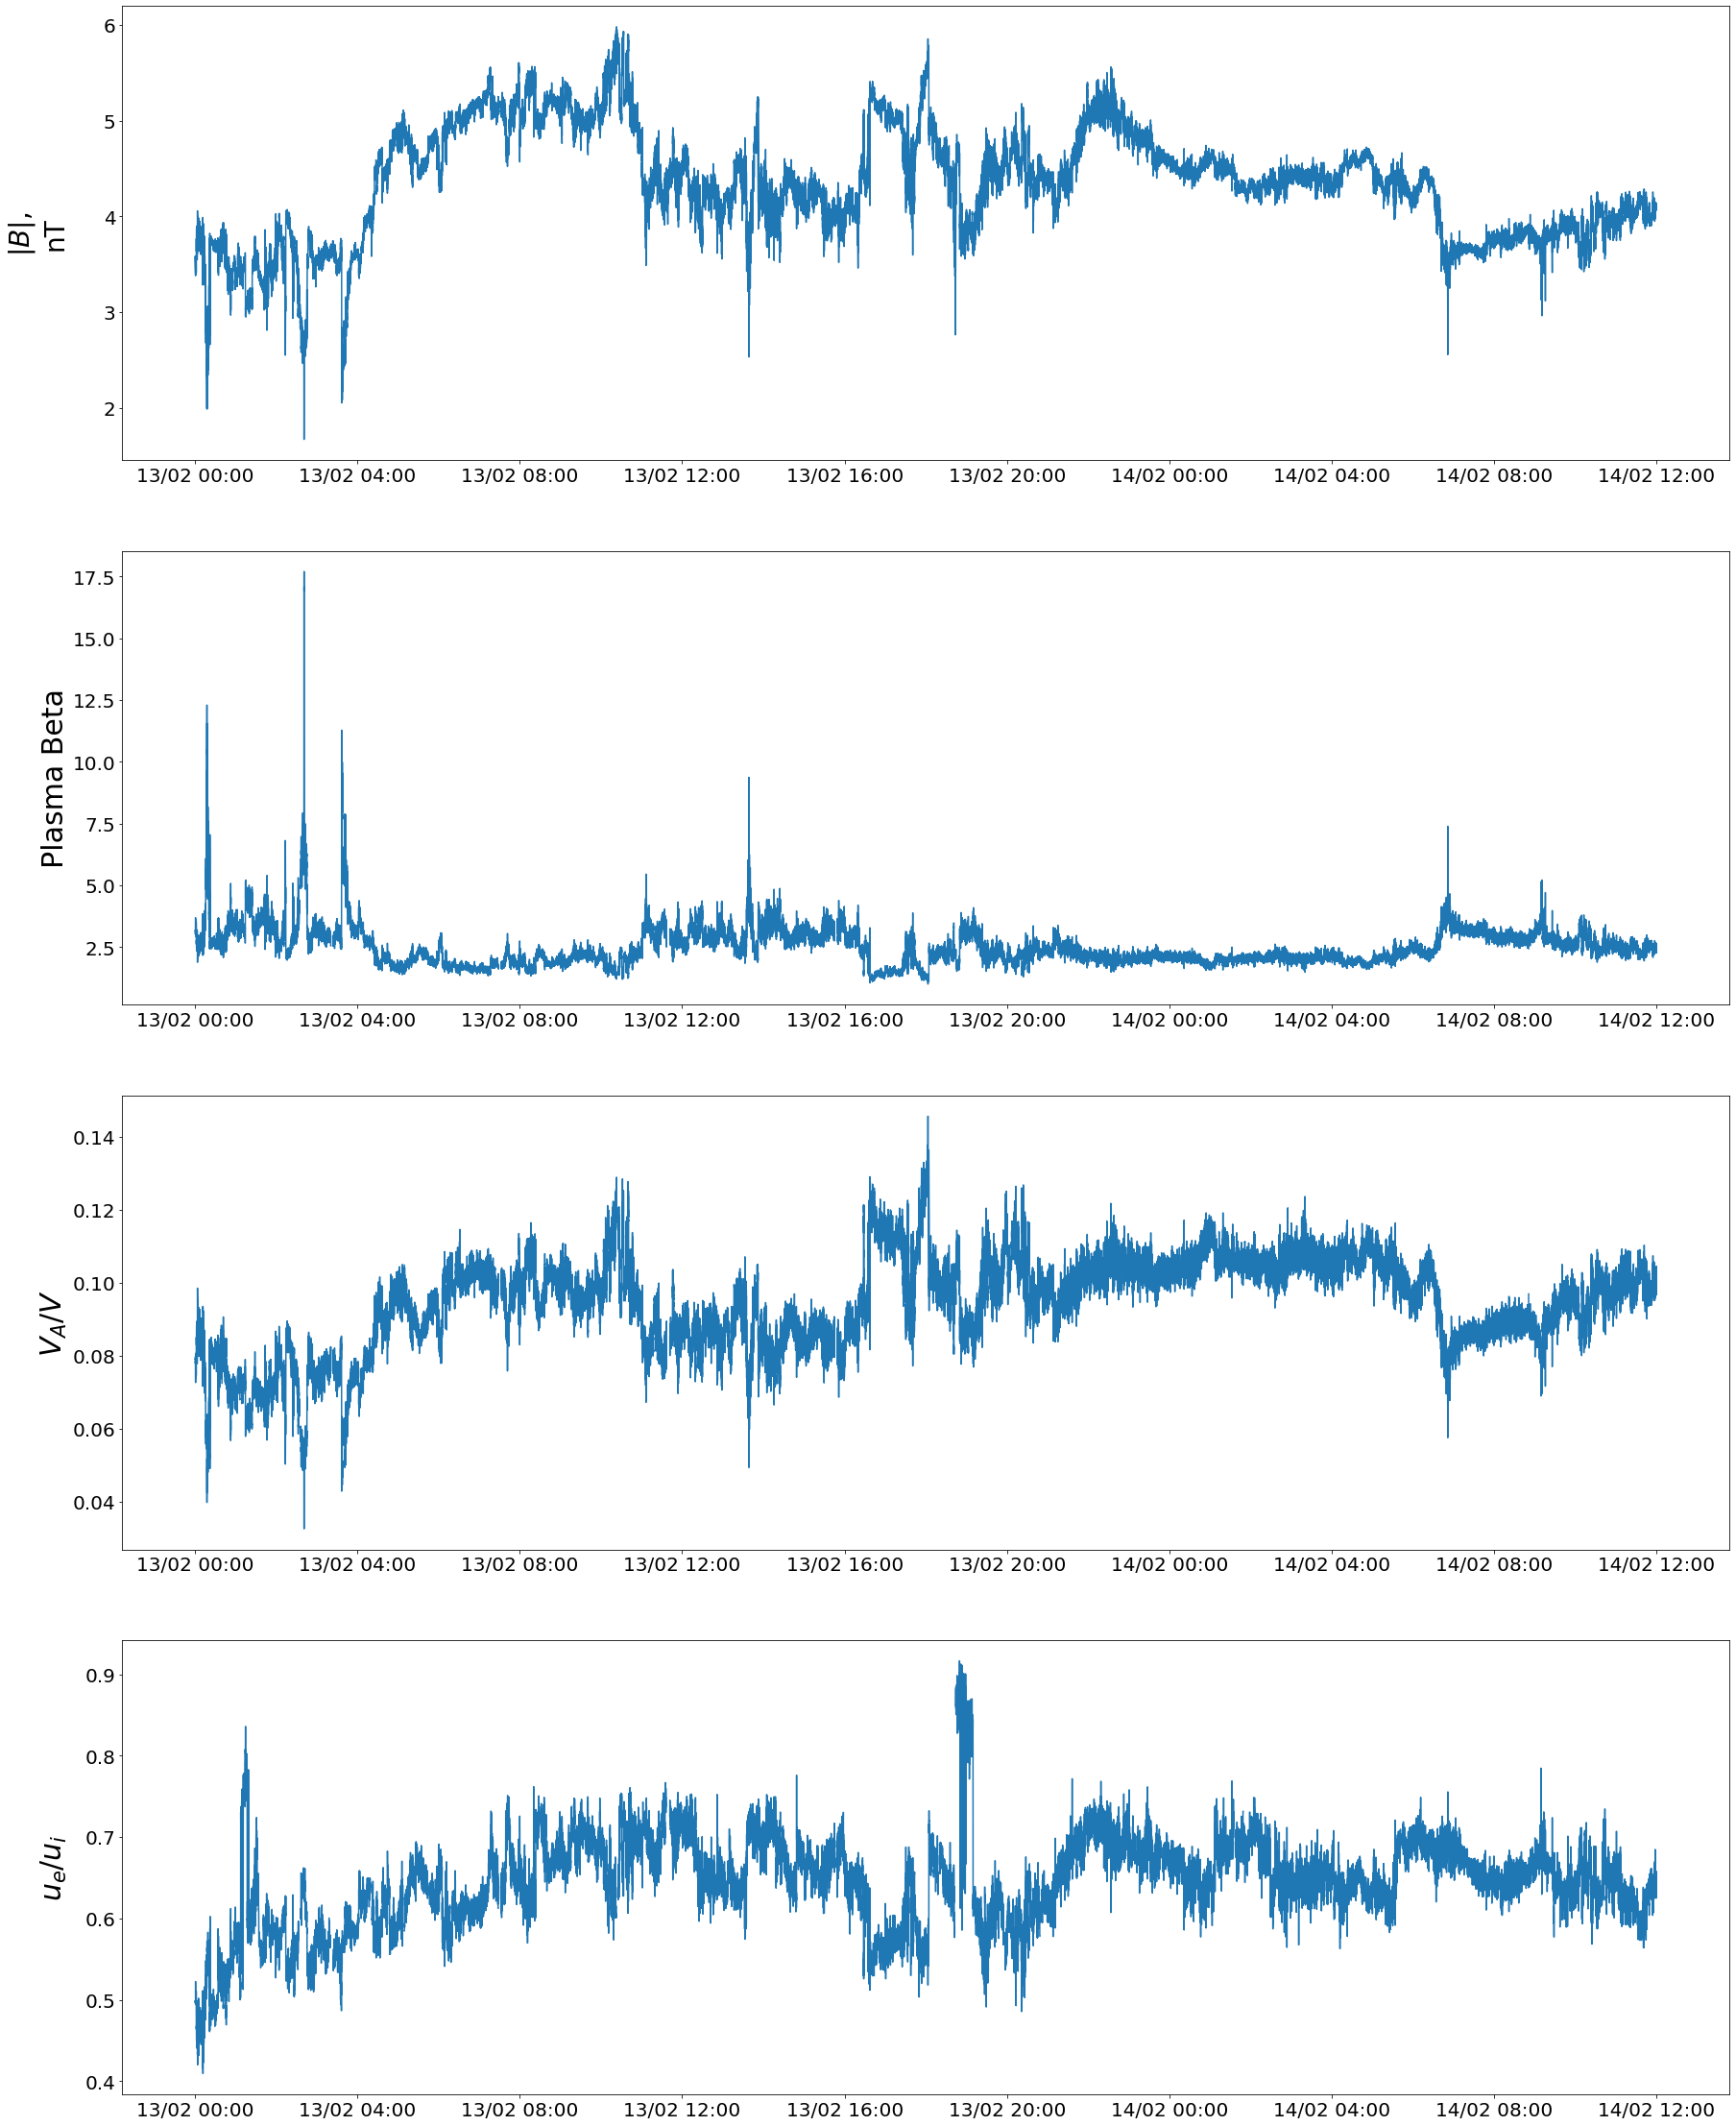

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
fig = plt.figure(1, figsize=(30,40))

ax1 = plt.subplot(411)
ax2 = plt.subplot(412)
ax3 = plt.subplot(413)
ax4 = plt.subplot(414)

ax1.plot(df['B_nT'])
ax2.plot(df['Beta'])
ax3.plot(df['VA/V'])
ax4.plot(df['ve/vp'])

ax1.set_ylabel('$|B|$,\nnT', fontsize=28)
#ax1.set_ylabel('nT', fontsize=30)
ax2.set_ylabel('Plasma Beta', fontsize=30)
ax3.set_ylabel('$V_A/V$', fontsize=30)
ax4.set_ylabel('$u_e/u_i$', fontsize=30)

myFmt = mdates.DateFormatter('%d/%m %H:%M')
ax1.xaxis.set_major_formatter(myFmt)
ax2.xaxis.set_major_formatter(myFmt)
ax3.xaxis.set_major_formatter(myFmt)
ax4.xaxis.set_major_formatter(myFmt)
fig.align_ylabels()
plt.savefig('buchner_10.jpeg',bbox_inches='tight')
plt.show()

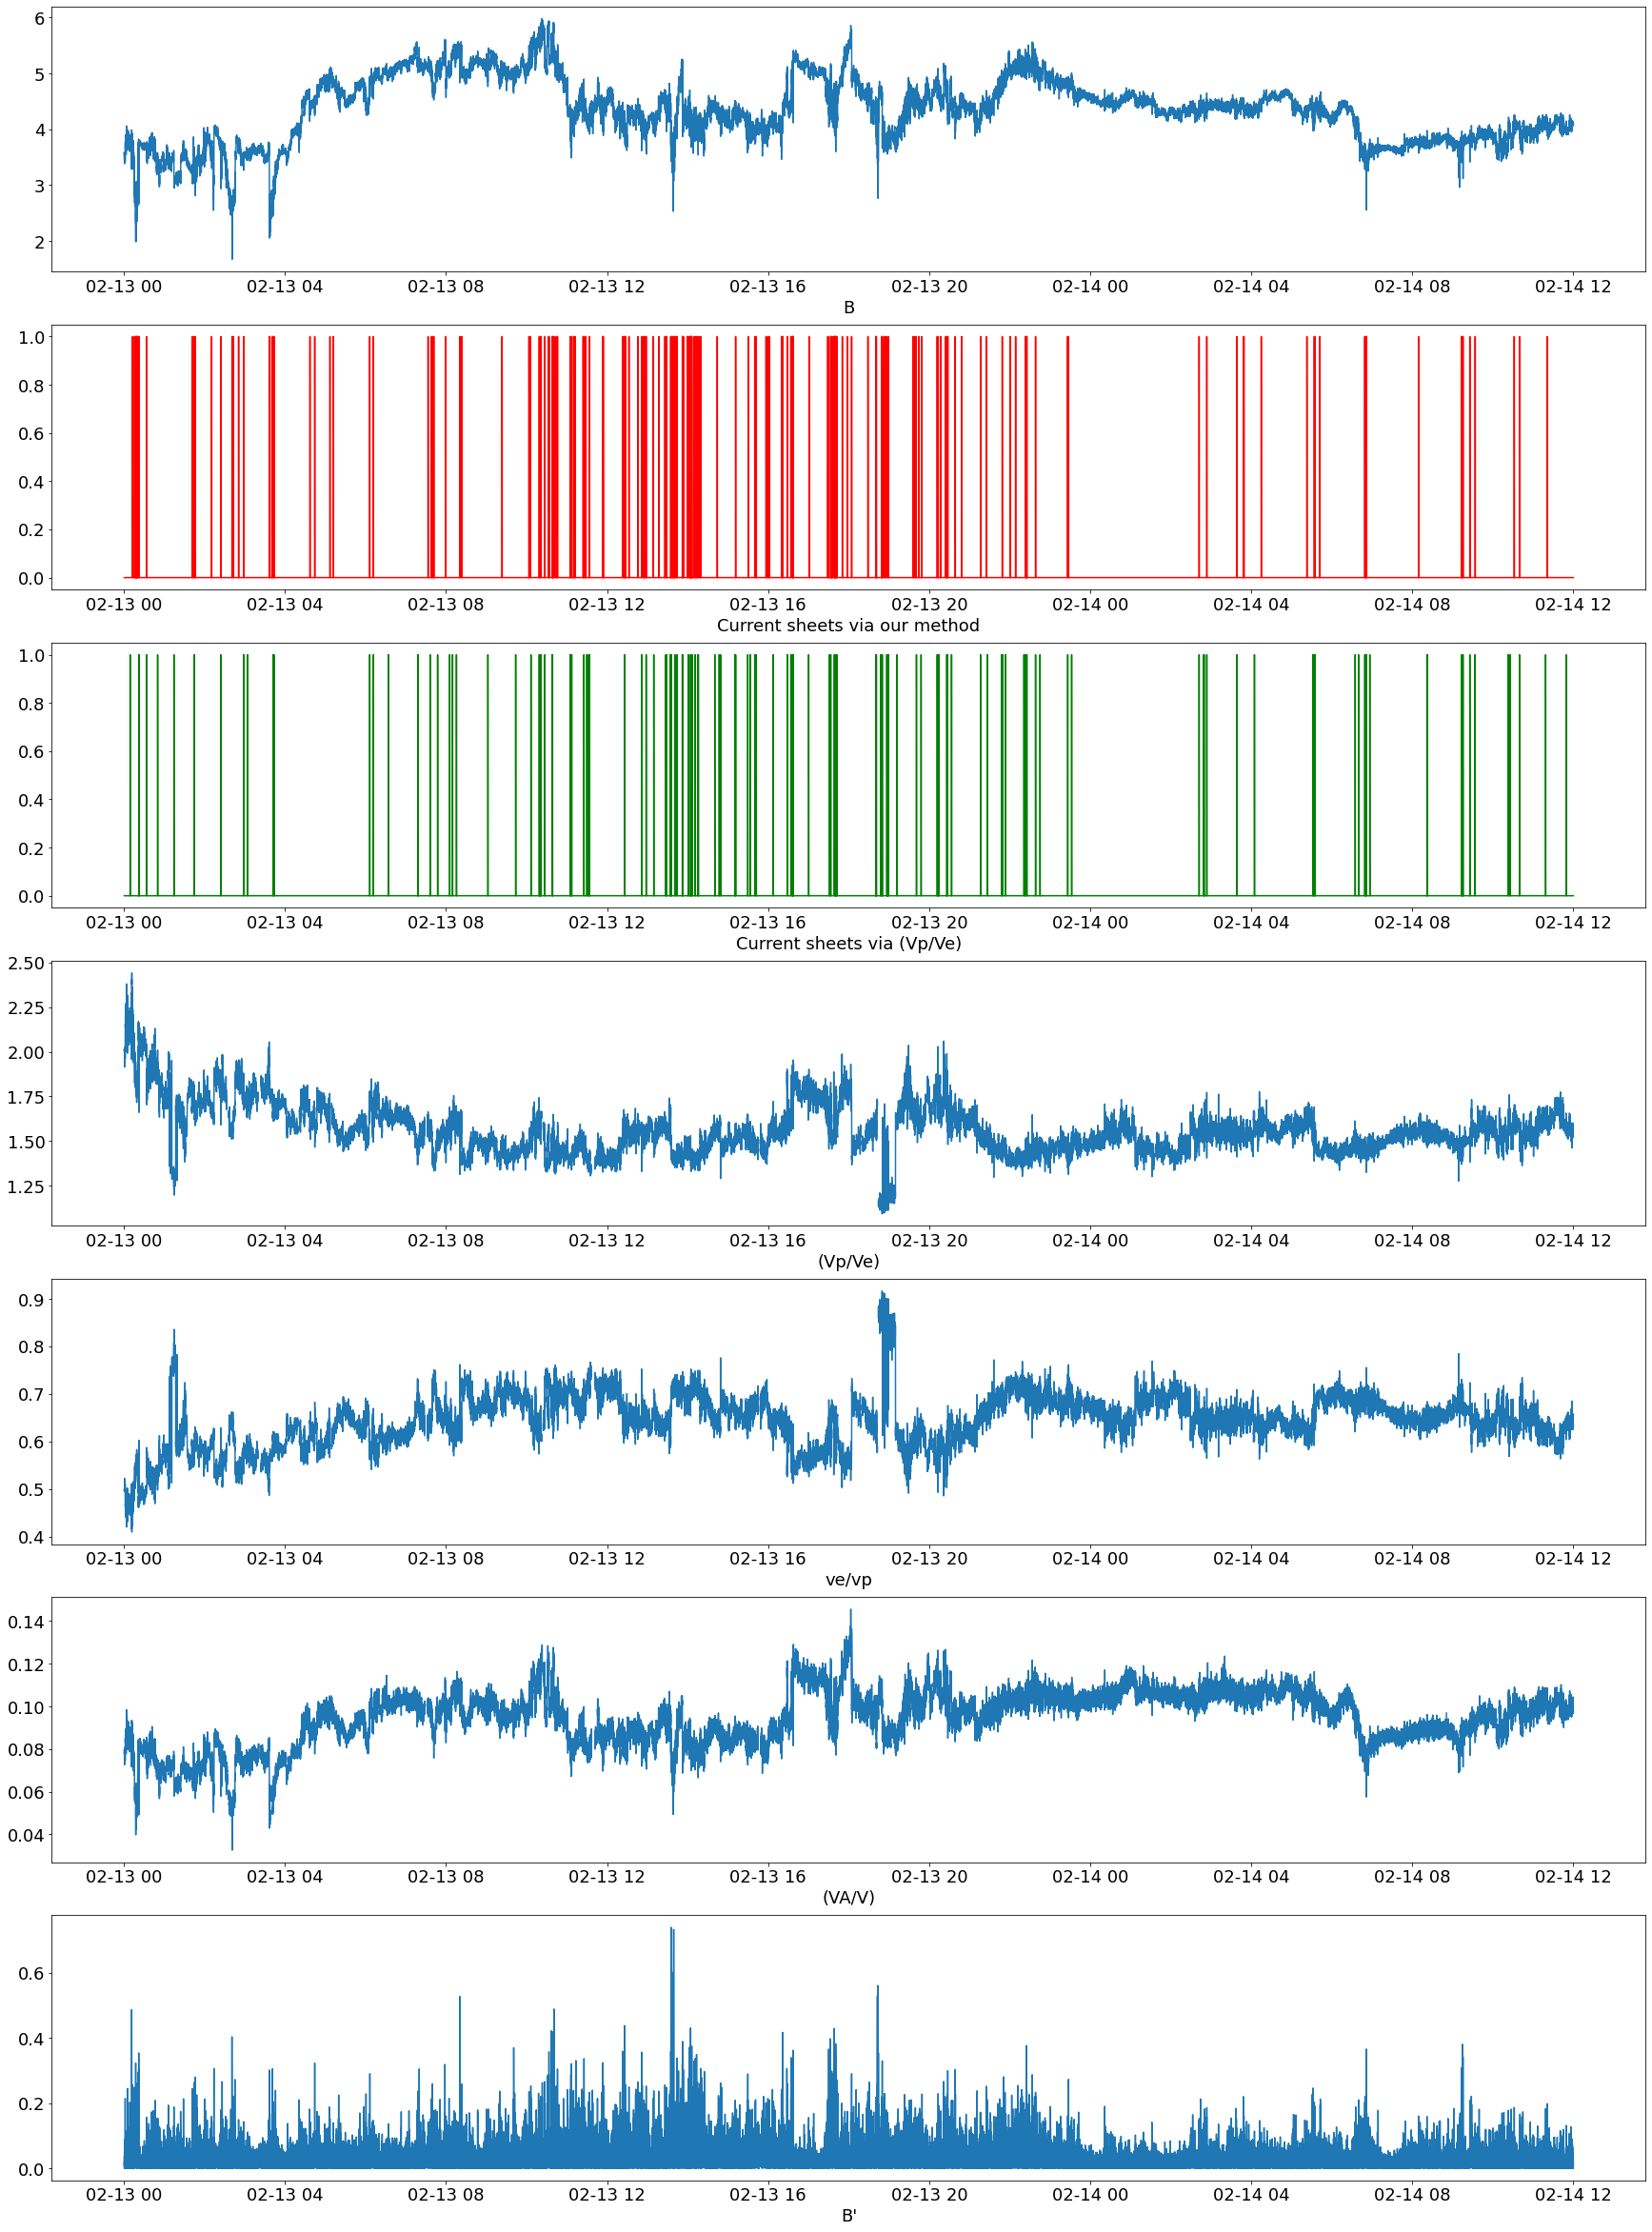

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(30,42))
ax1 = plt.subplot(711)
ax1.plot(df['B_nT'])
ax2 = plt.subplot(712)
ax2.plot(df['current_sheet_v2'], 'r')
ax3 = plt.subplot(713)
ax3.plot(df['current_sheet_buchner_v2'], 'g')
ax4 = plt.subplot(714)
ax4.plot(df['vp/ve'].abs())
ax5 = plt.subplot(715)
ax5.plot((df['ve'] / df['vp']).abs())
ax6 = plt.subplot(716)
ax6.plot(df['VA/V'].abs())
ax7 = plt.subplot(717)
ax7.plot(df['B_der'].abs())
ax3.set_xlabel("Current sheets via (Vp/Ve)")
ax2.set_xlabel('Current sheets via our method')
ax1.set_xlabel('B')
ax5.set_xlabel('ve/vp')
ax4.set_xlabel("(Vp/Ve)")
ax6.set_xlabel("(VA/V)")
ax7.set_xlabel("B'")
plt.show()

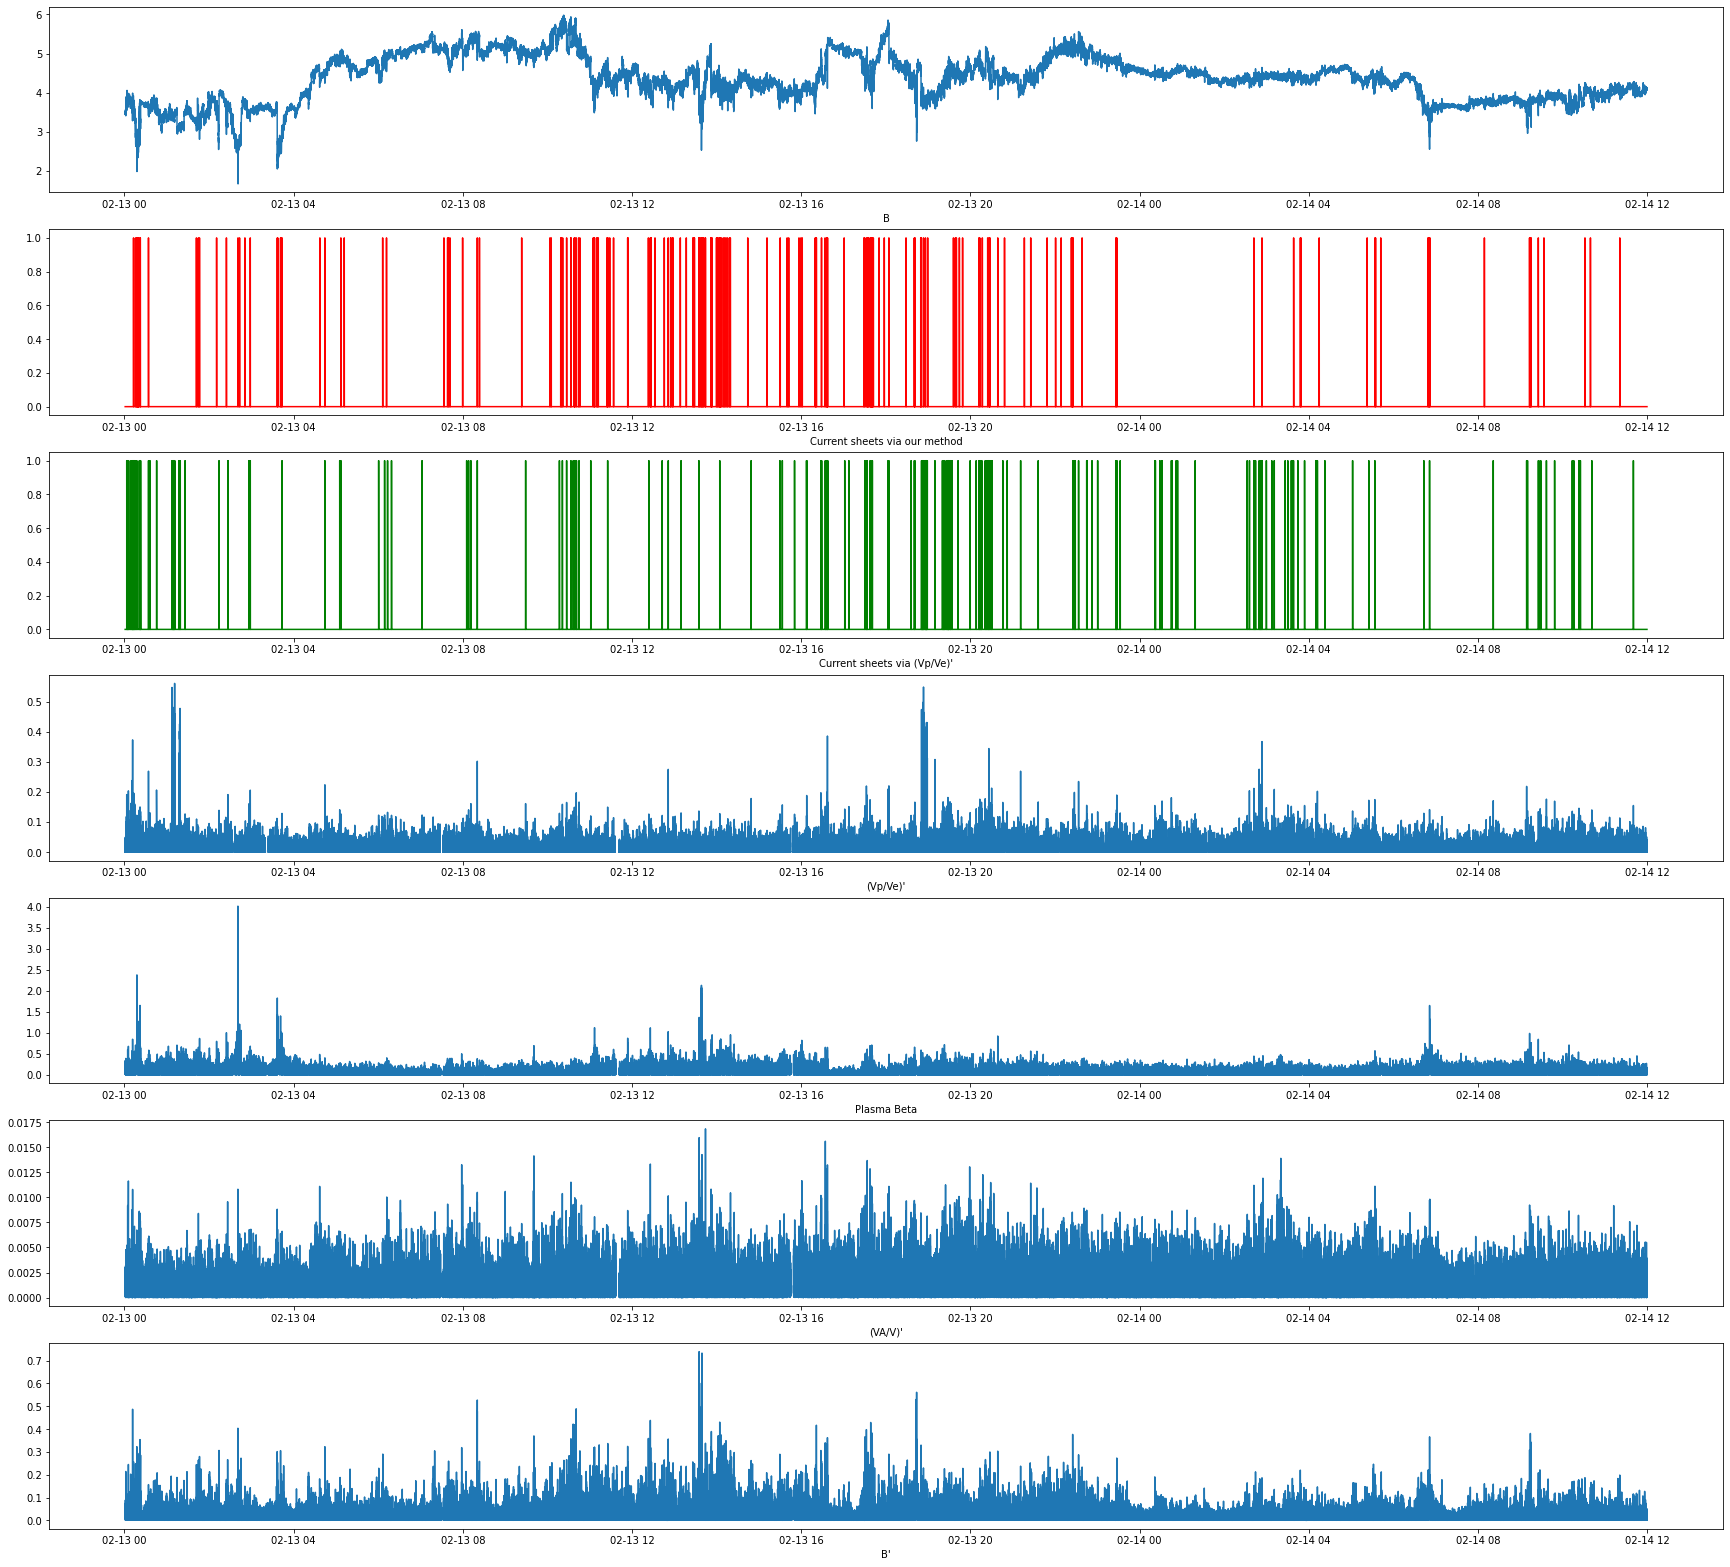

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(30,28))
ax1 = plt.subplot(711)
ax1.plot(df['B_nT'])
ax2 = plt.subplot(712)
ax2.plot(df['current_sheet_v2'], 'r')
ax3 = plt.subplot(713)
ax3.plot(df['current_sheet_buchner'], 'g')
ax4 = plt.subplot(714)
ax4.plot(df['vp/ve_der'].abs())
ax5 = plt.subplot(715)
ax5.plot(df['Beta_der'].abs())
ax6 = plt.subplot(716)
ax6.plot(df['VA/V_der'].abs())
ax7 = plt.subplot(717)
ax7.plot(df['B_der'].abs())
ax3.set_xlabel("Current sheets via (Vp/Ve)'")
ax2.set_xlabel('Current sheets via our method')
ax1.set_xlabel('B')
ax5.set_xlabel('Plasma Beta')
ax4.set_xlabel("(Vp/Ve)'")
ax6.set_xlabel("(VA/V)'")
ax7.set_xlabel("B'")
plt.show()

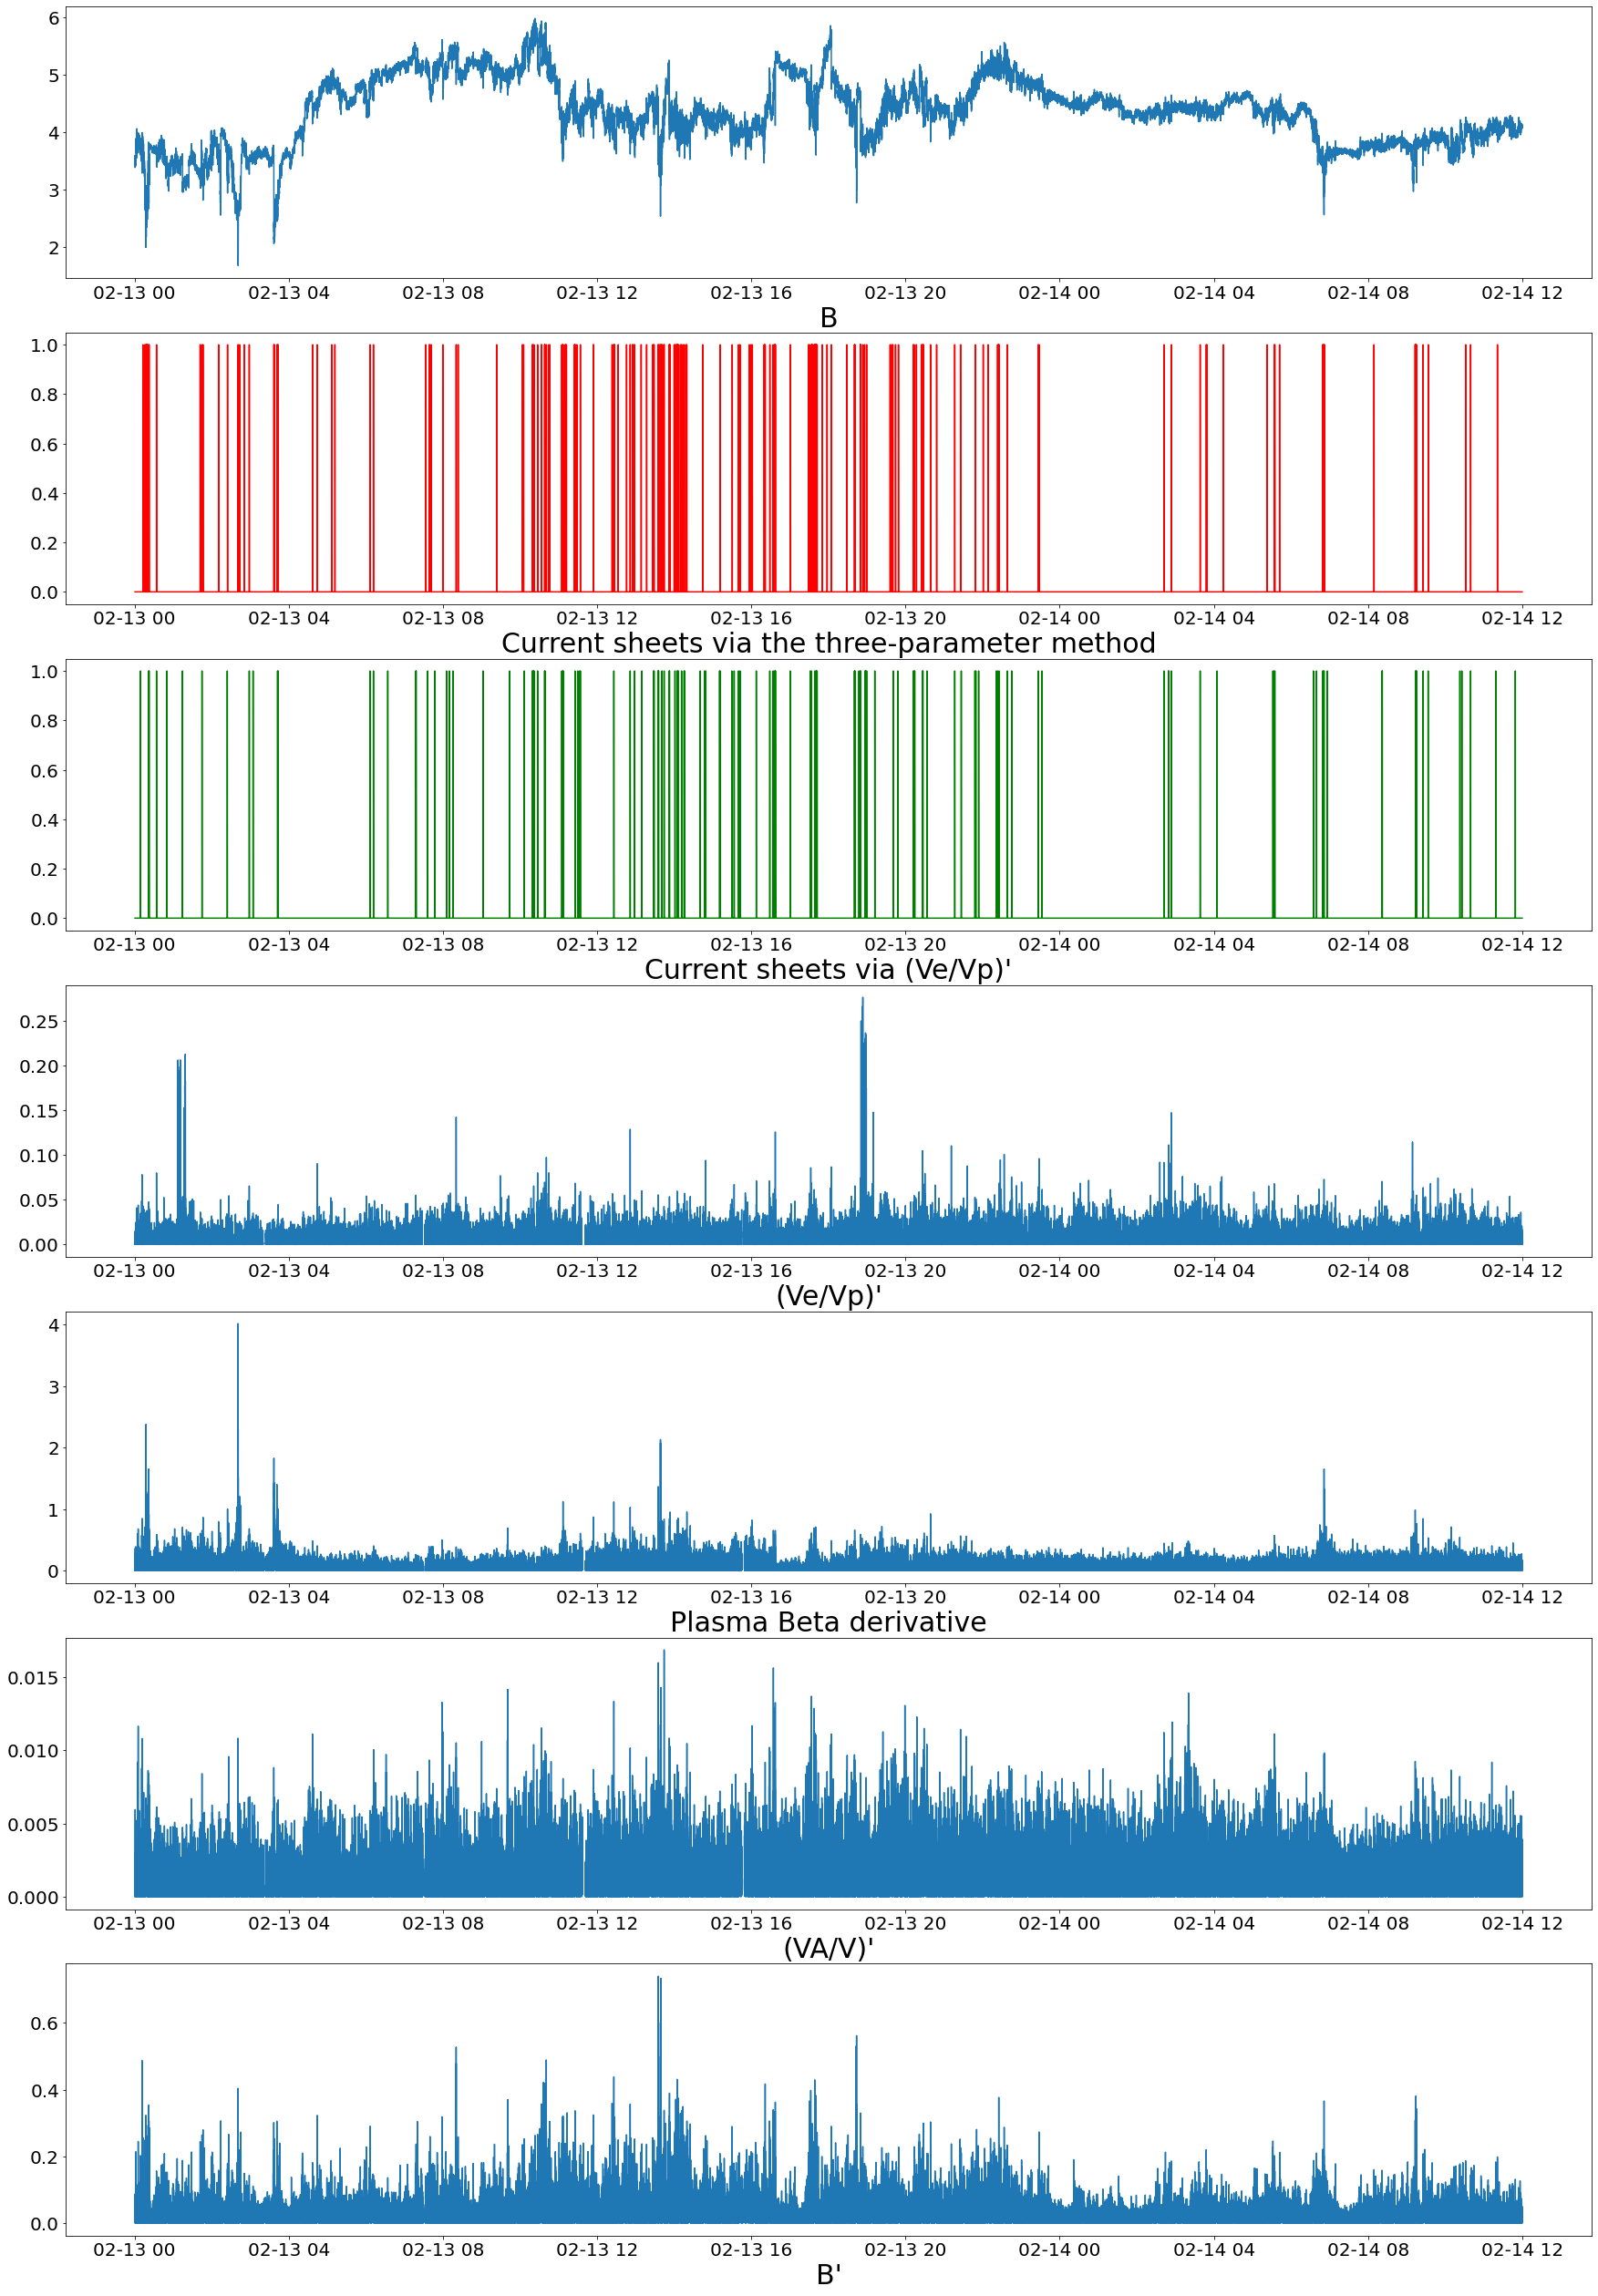

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(30,45))
ax1 = plt.subplot(711)
ax1.plot(df['B_nT'])
ax2 = plt.subplot(712)
ax2.plot(df['current_sheet_v2'], 'r')
ax3 = plt.subplot(713)
ax3.plot(df['current_sheet_buchner_v2'], 'g')
ax4 = plt.subplot(714)
ax4.plot(df['ve/vp_der'].abs())
ax5 = plt.subplot(715)
ax5.plot(df['Beta_der'].abs())
ax6 = plt.subplot(716)
ax6.plot(df['VA/V_der'].abs())
ax7 = plt.subplot(717)
ax7.plot(df['B_der'].abs())
ax3.set_xlabel("Current sheets via (Ve/Vp)'", fontsize=30)
ax2.set_xlabel('Current sheets via the three-parameter method', fontsize=30)
ax1.set_xlabel('B', fontsize=30)
ax5.set_xlabel('Plasma Beta derivative', fontsize=30)
ax4.set_xlabel("(Ve/Vp)'", fontsize=30)
ax6.set_xlabel("(VA/V)'", fontsize=30)
ax7.set_xlabel("B'", fontsize=30)
plt.show()

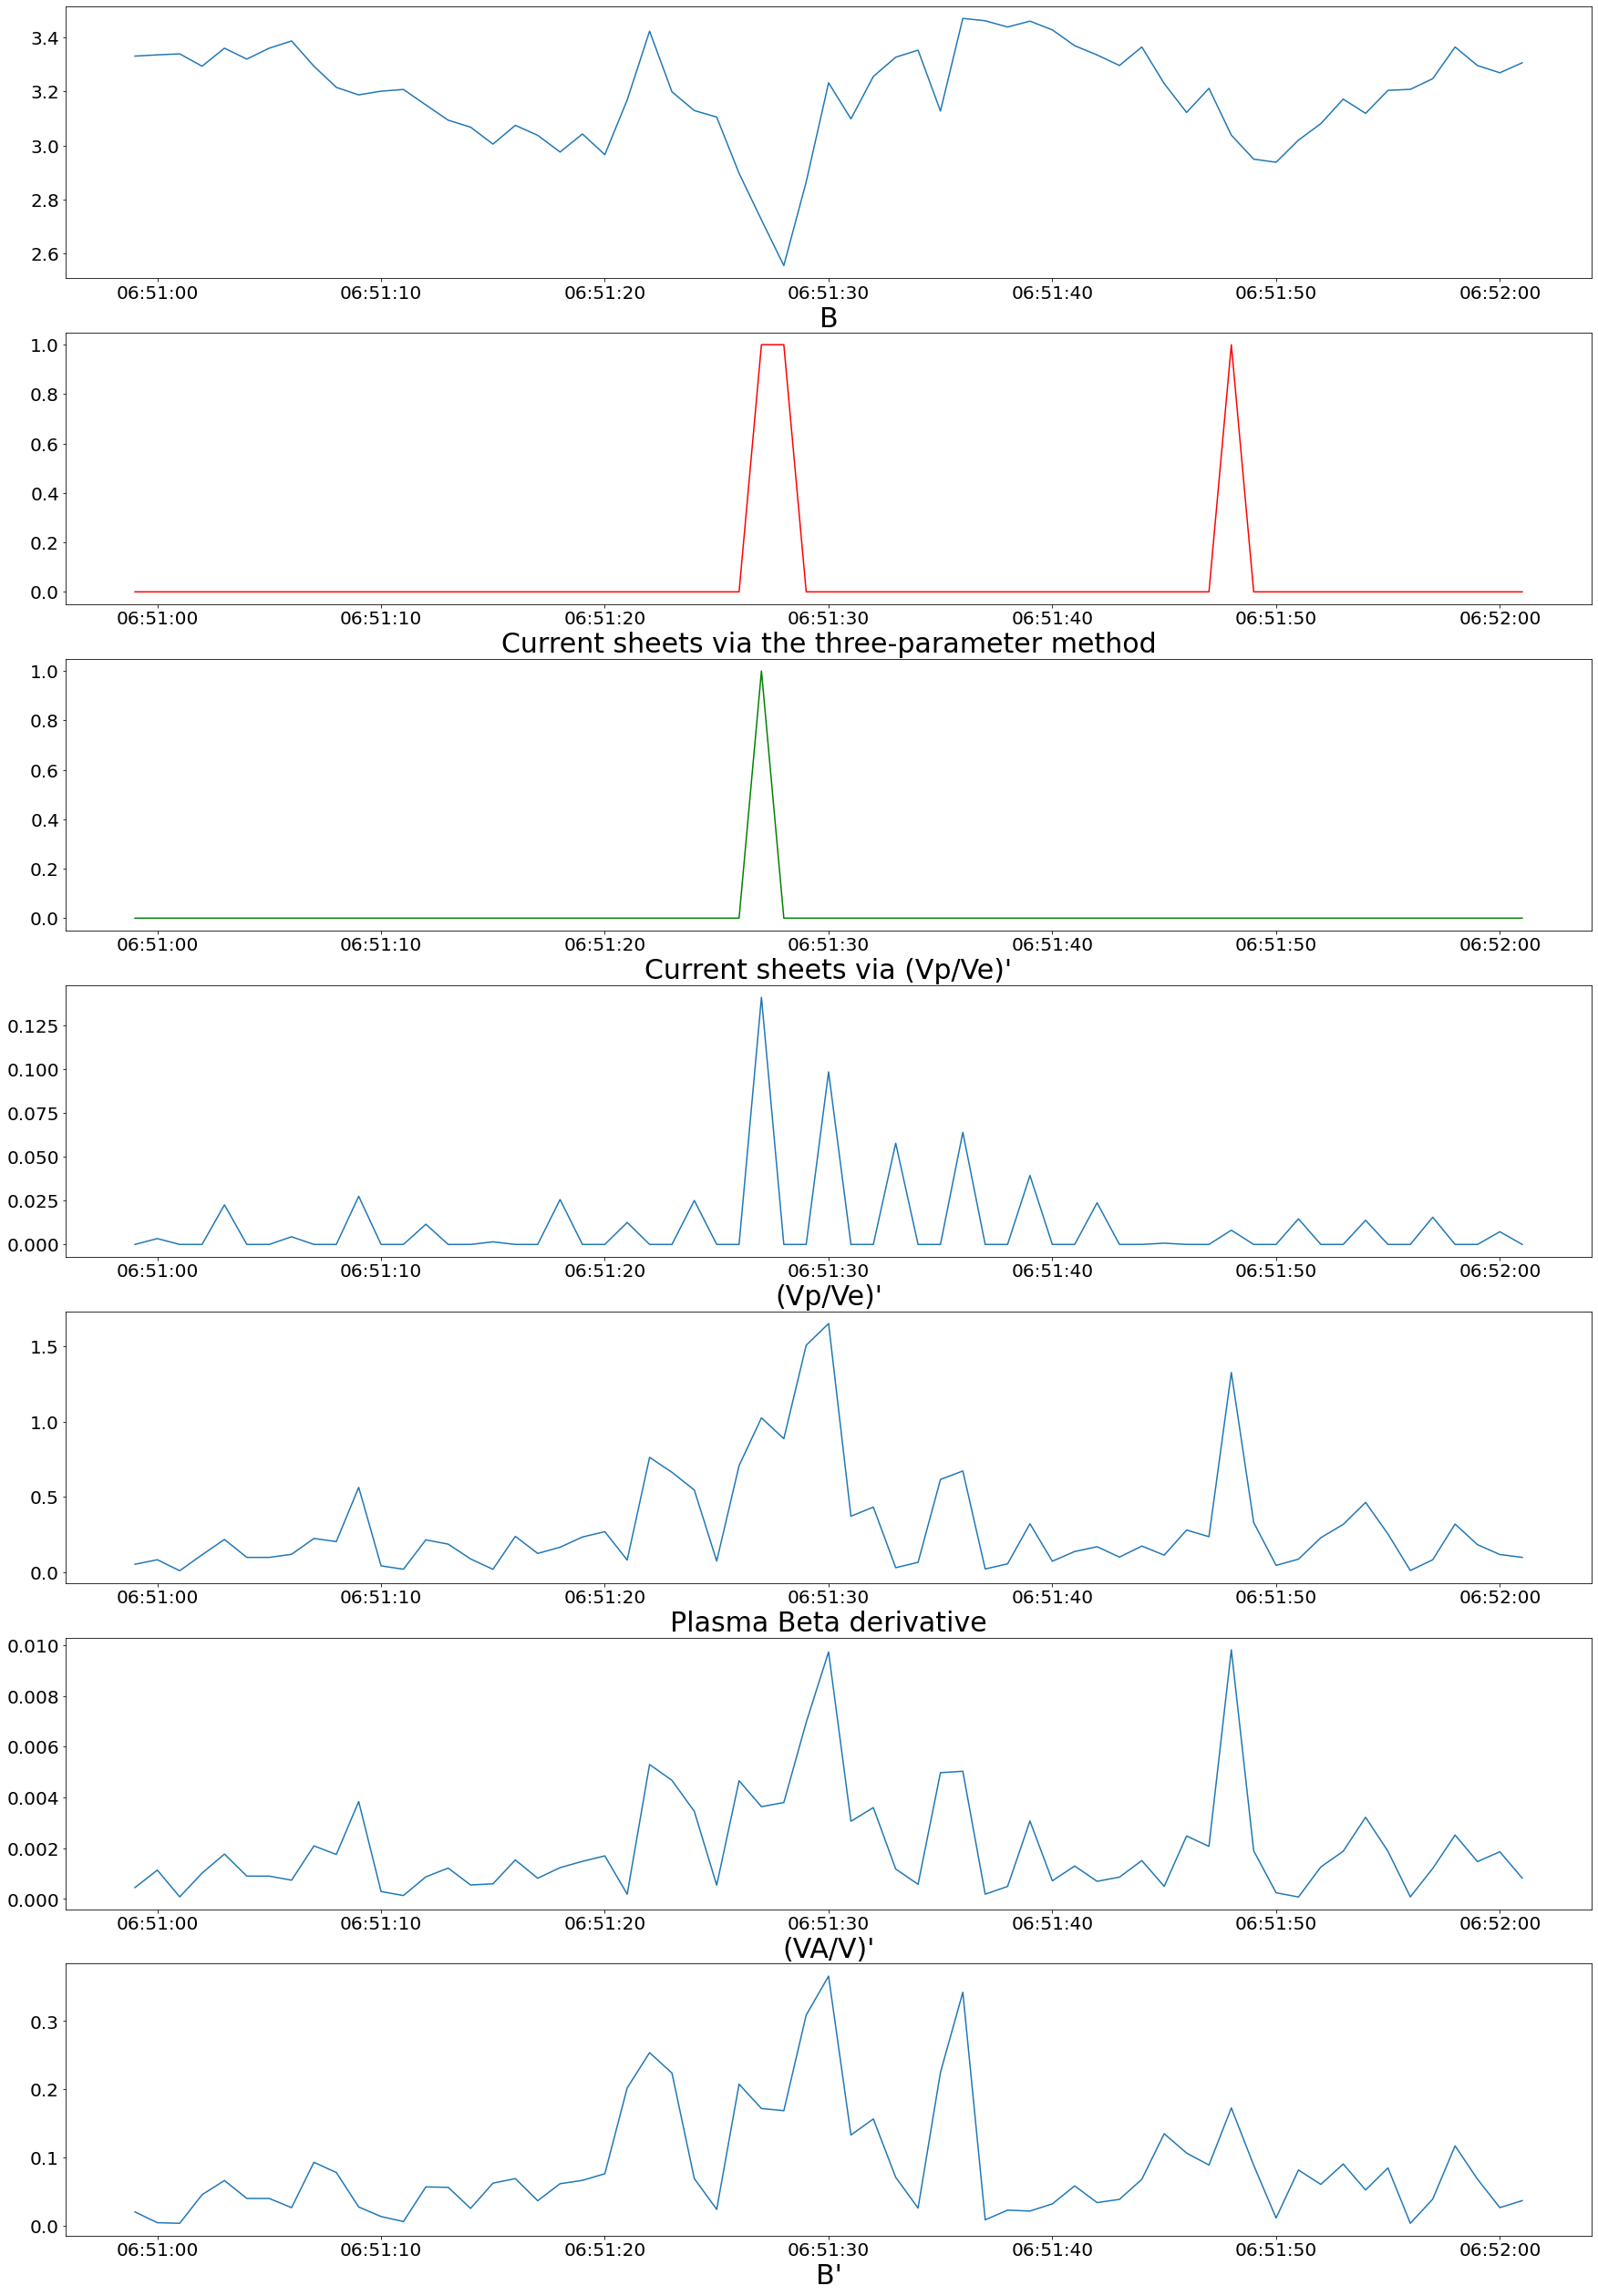

In [ ]:
import matplotlib.pyplot as plt
x, y = 111030,111093
fig = plt.figure(1, figsize=(30,45))
ax1 = plt.subplot(711)
ax1.plot(df['B_nT'][x:y])
ax2 = plt.subplot(712)
ax2.plot(df['current_sheet_v2'][x:y], 'r')
ax3 = plt.subplot(713)
ax3.plot(df['current_sheet_buchner'][x:y], 'g')
ax4 = plt.subplot(714)
ax4.plot(df['vp/ve_der'].abs()[x:y])
ax5 = plt.subplot(715)
ax5.plot(df['Beta_der'].abs()[x:y])
ax6 = plt.subplot(716)
ax6.plot(df['VA/V_der'].abs()[x:y])
ax7 = plt.subplot(717)
ax7.plot(df['B_der'].abs()[x:y])
ax3.set_xlabel("Current sheets via (Vp/Ve)'", fontsize=30)
ax2.set_xlabel('Current sheets via the three-parameter method', fontsize=30)
ax1.set_xlabel('B', fontsize=30)
ax5.set_xlabel('Plasma Beta derivative', fontsize=30)
ax4.set_xlabel("(Vp/Ve)'", fontsize=30)
ax6.set_xlabel("(VA/V)'", fontsize=30)
ax7.set_xlabel("B'", fontsize=30)
plt.show()

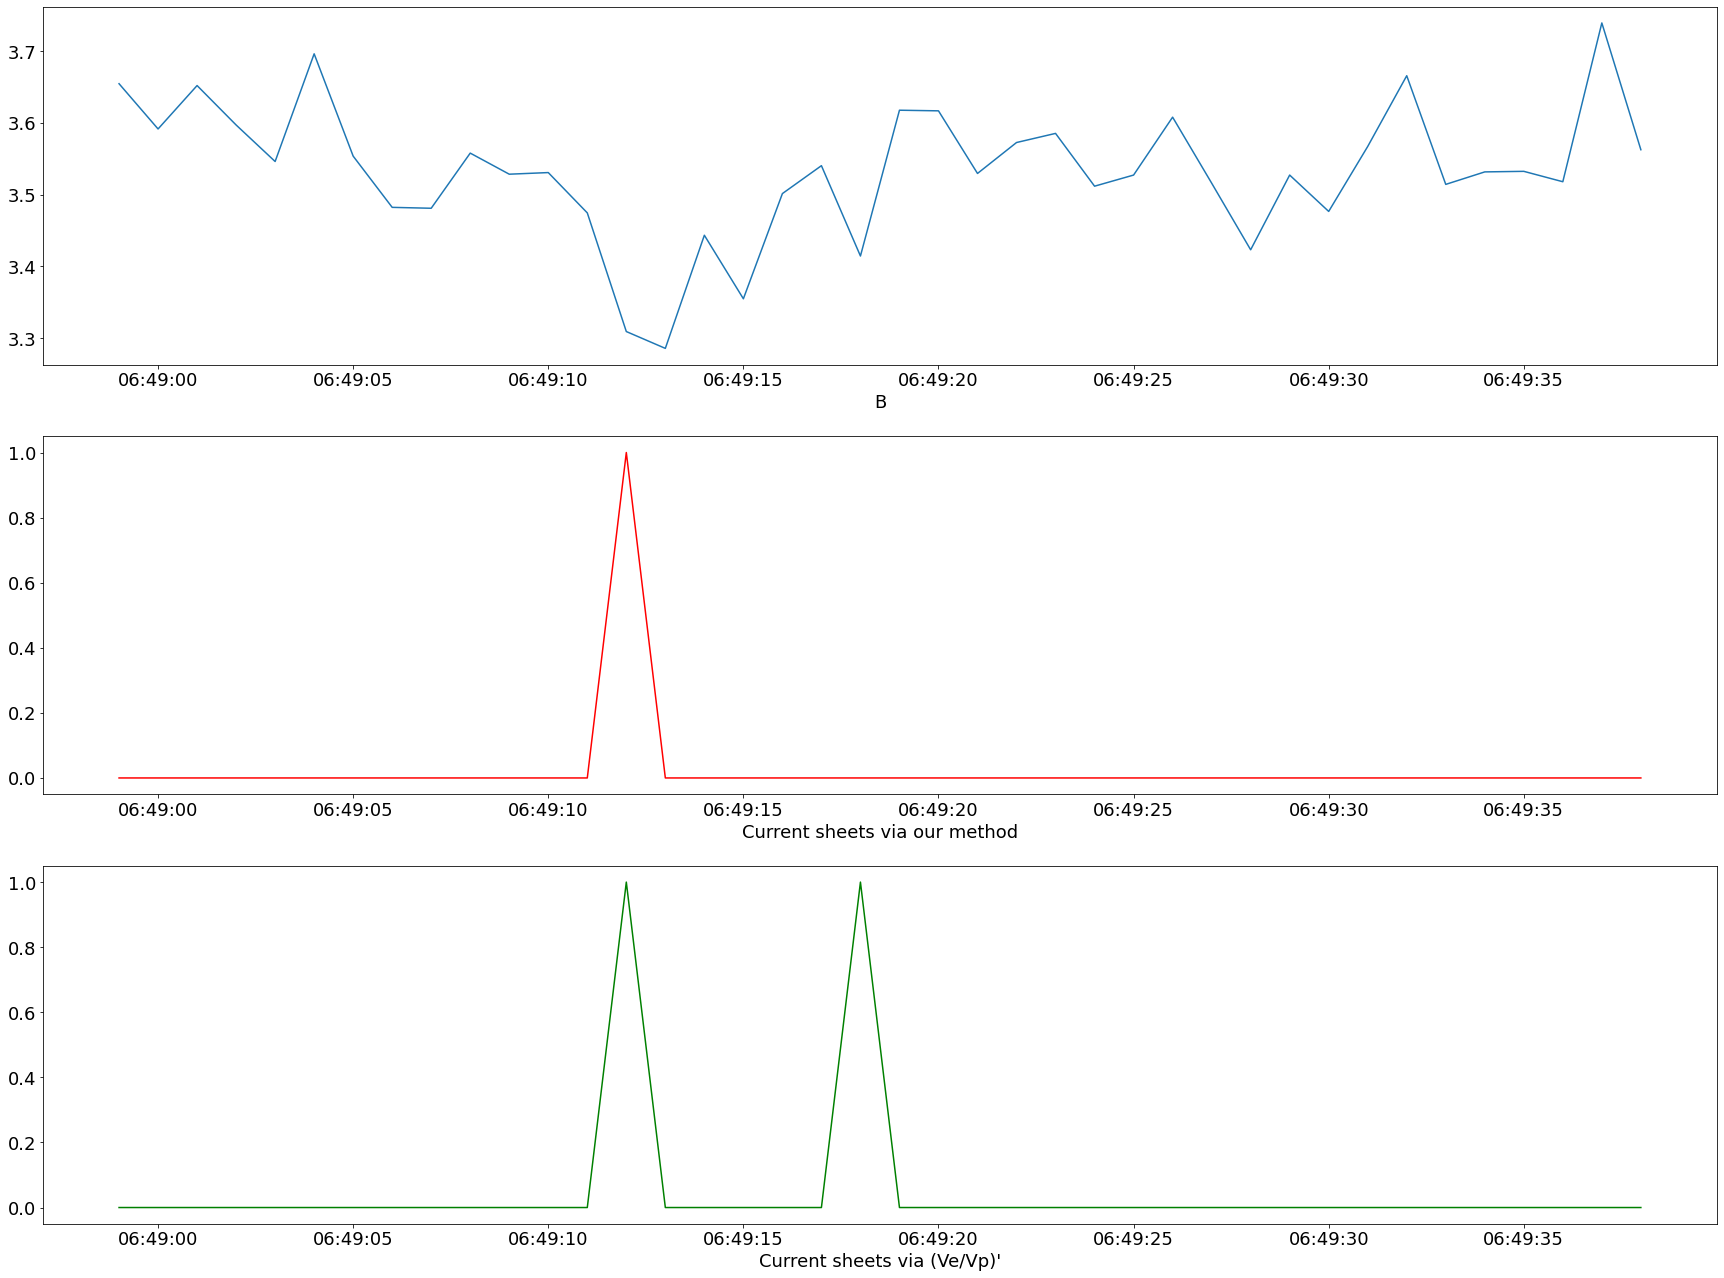

In [ ]:
left = 110910
right = 110950
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(30,54))
plt.rcParams.update({'font.size': 18})
ax1 = plt.subplot(711)
ax1.plot(df['B_nT'][left:right])
ax2 = plt.subplot(712)
ax2.plot(df['current_sheet_v2'][left:right], 'r')
ax3 = plt.subplot(713)
ax3.plot(df['current_sheet_buchner_v2'][left:right], 'g')
ax3.set_xlabel("Current sheets via (Ve/Vp)'")
ax2.set_xlabel('Current sheets via our method')
ax1.set_xlabel('B')
import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%H:%M:%S')
ax1.xaxis.set_major_formatter(myFmt)
#plt.setp(ax1.xaxis.get_majorticklabels(), rotation=1)

ax2.xaxis.set_major_formatter(myFmt)
#plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

ax3.xaxis.set_major_formatter(myFmt)
#plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
plt.show()

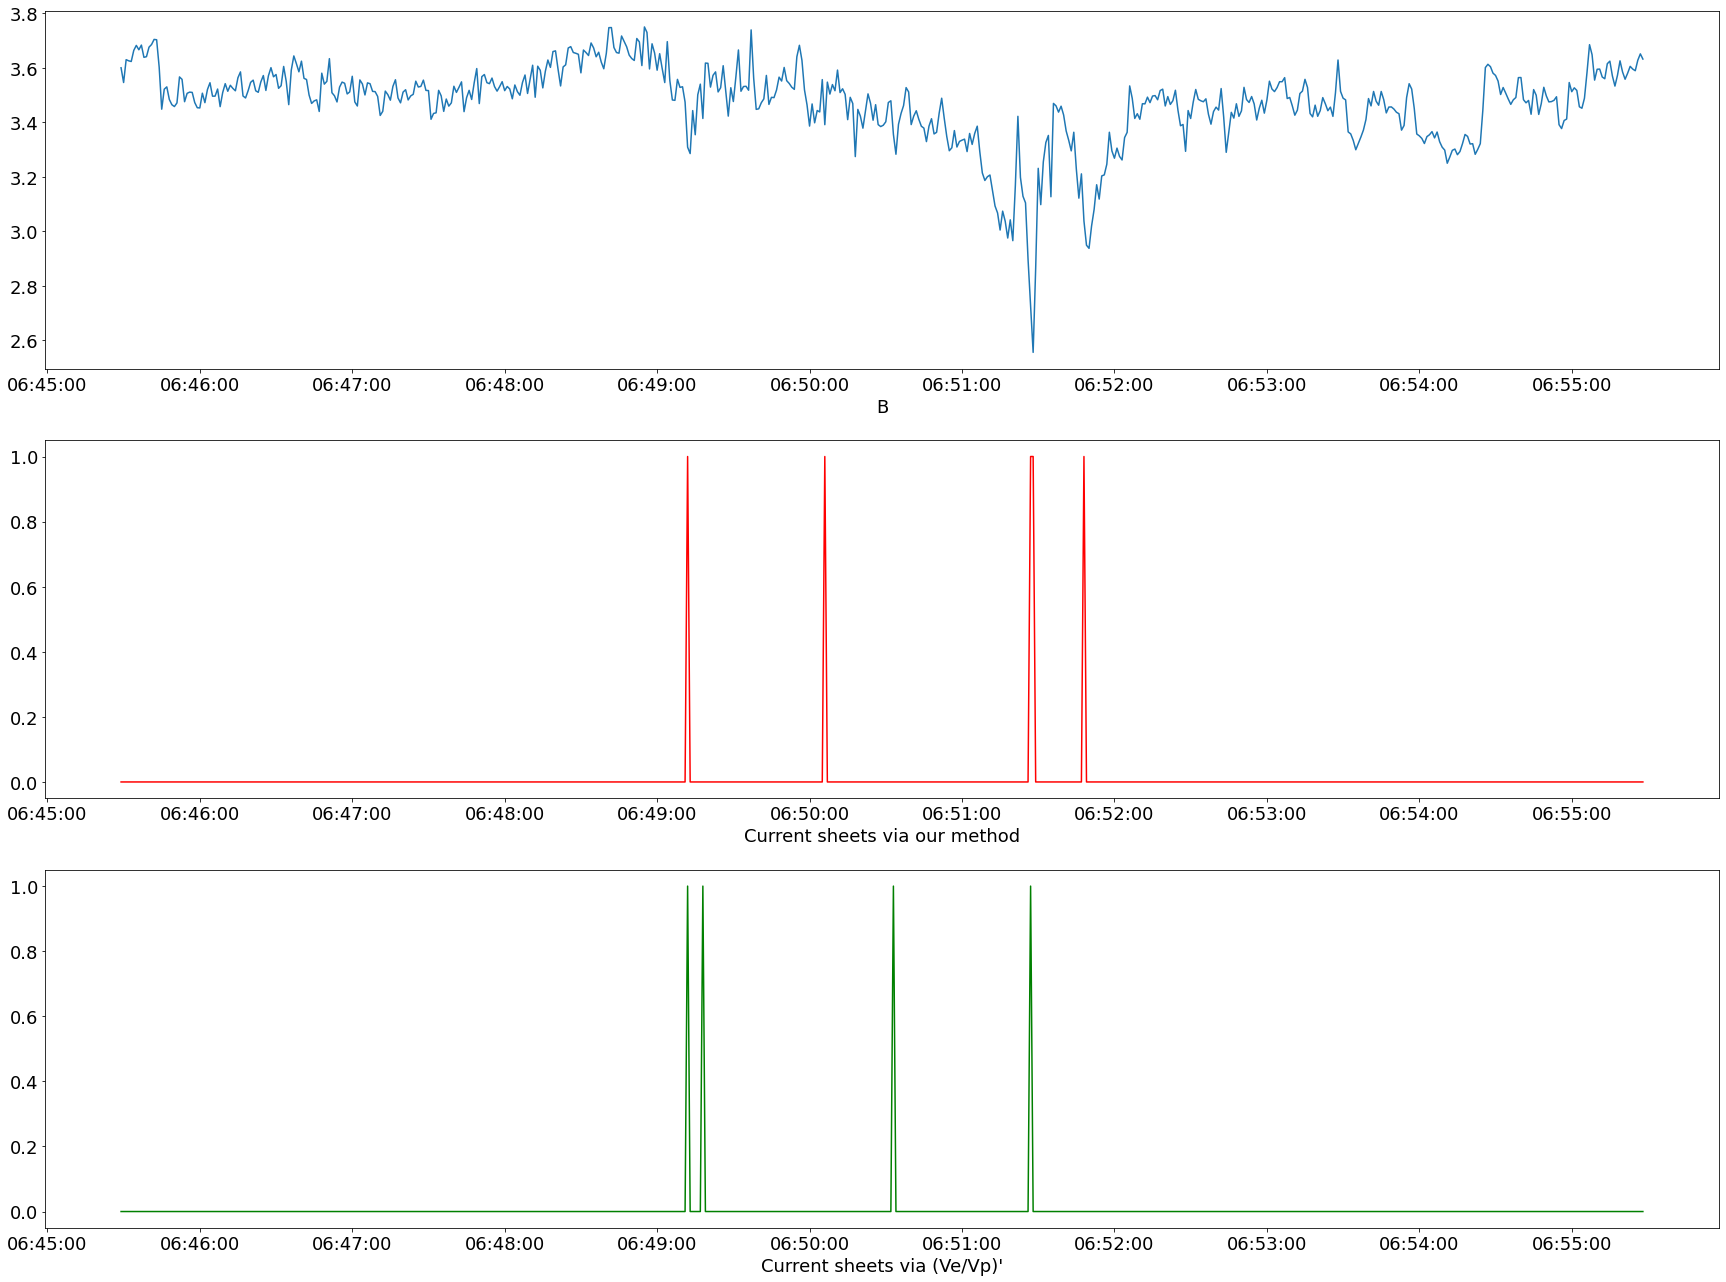

In [ ]:
left = 110700
right = 111300
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(30,54))
plt.rcParams.update({'font.size': 18})
ax1 = plt.subplot(711)
ax1.plot(df['B_nT'][left:right])
ax2 = plt.subplot(712)
ax2.plot(df['current_sheet_v2'][left:right], 'r')
ax3 = plt.subplot(713)
ax3.plot(df['current_sheet_buchner_v2'][left:right], 'g')
ax3.set_xlabel("Current sheets via (Ve/Vp)'")
ax2.set_xlabel('Current sheets via our method')
ax1.set_xlabel('B')
import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%H:%M:%S')
ax1.xaxis.set_major_formatter(myFmt)
#plt.setp(ax1.xaxis.get_majorticklabels(), rotation=1)

ax2.xaxis.set_major_formatter(myFmt)
#plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

ax3.xaxis.set_major_formatter(myFmt)
#plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
plt.show()

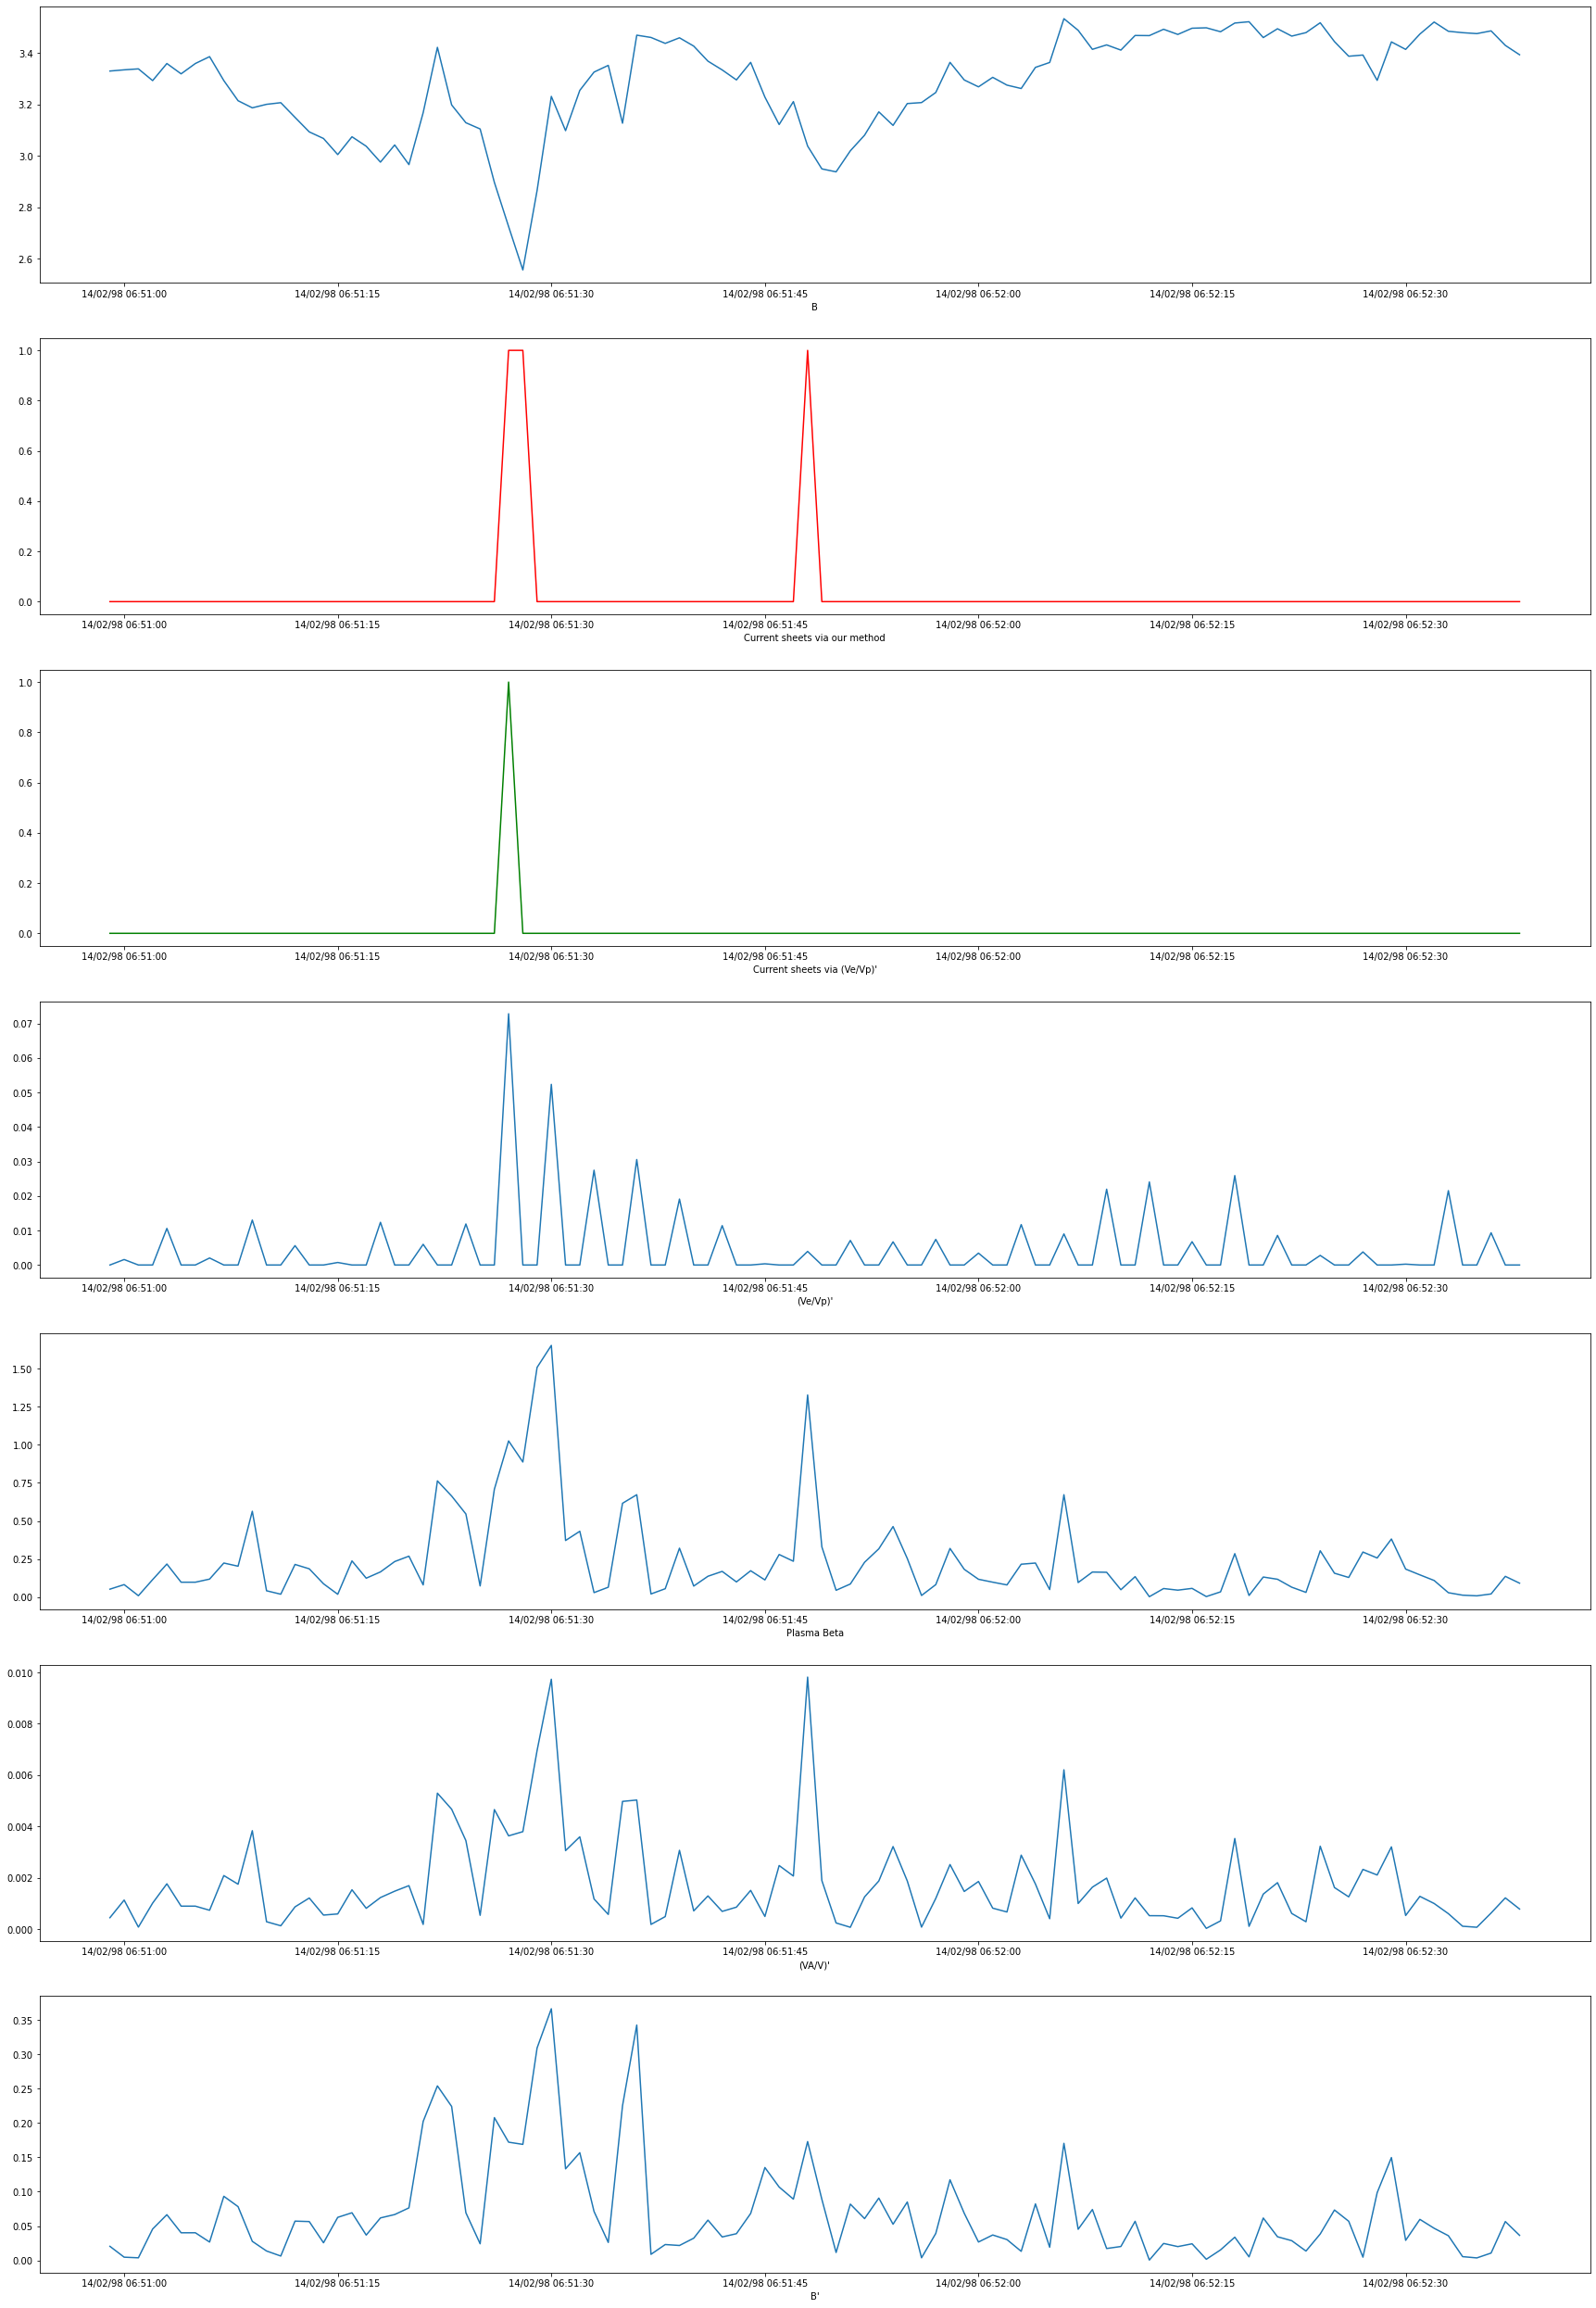

In [ ]:
left = 111030
right = 111130
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(30,45))
ax1 = plt.subplot(711)
ax1.plot(df['B_nT'][left:right])
ax2 = plt.subplot(712)
ax2.plot(df['current_sheet_v2'][left:right], 'r')
ax3 = plt.subplot(713)
ax3.plot(df['current_sheet_buchner_v2'][left:right], 'g')
ax4 = plt.subplot(714)
ax4.plot(df['ve/vp_der'].abs()[left:right])
ax5 = plt.subplot(715)
ax5.plot(df['Beta_der'].abs()[left:right])
ax6 = plt.subplot(716)
ax6.plot(df['VA/V_der'].abs()[left:right])
ax7 = plt.subplot(717)
ax7.plot(df['B_der'].abs()[left:right])
ax3.set_xlabel("Current sheets via (Ve/Vp)'")
ax2.set_xlabel('Current sheets via our method')
ax1.set_xlabel('B')
ax5.set_xlabel('Plasma Beta')
ax4.set_xlabel("(Ve/Vp)'")
ax6.set_xlabel("(VA/V)'")
ax7.set_xlabel("B'")
import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%d/%m/%y %H:%M:%S')
ax1.xaxis.set_major_formatter(myFmt)
ax2.xaxis.set_major_formatter(myFmt)
ax3.xaxis.set_major_formatter(myFmt)
ax4.xaxis.set_major_formatter(myFmt)
ax5.xaxis.set_major_formatter(myFmt)
ax6.xaxis.set_major_formatter(myFmt)
ax7.xaxis.set_major_formatter(myFmt)
plt.show()

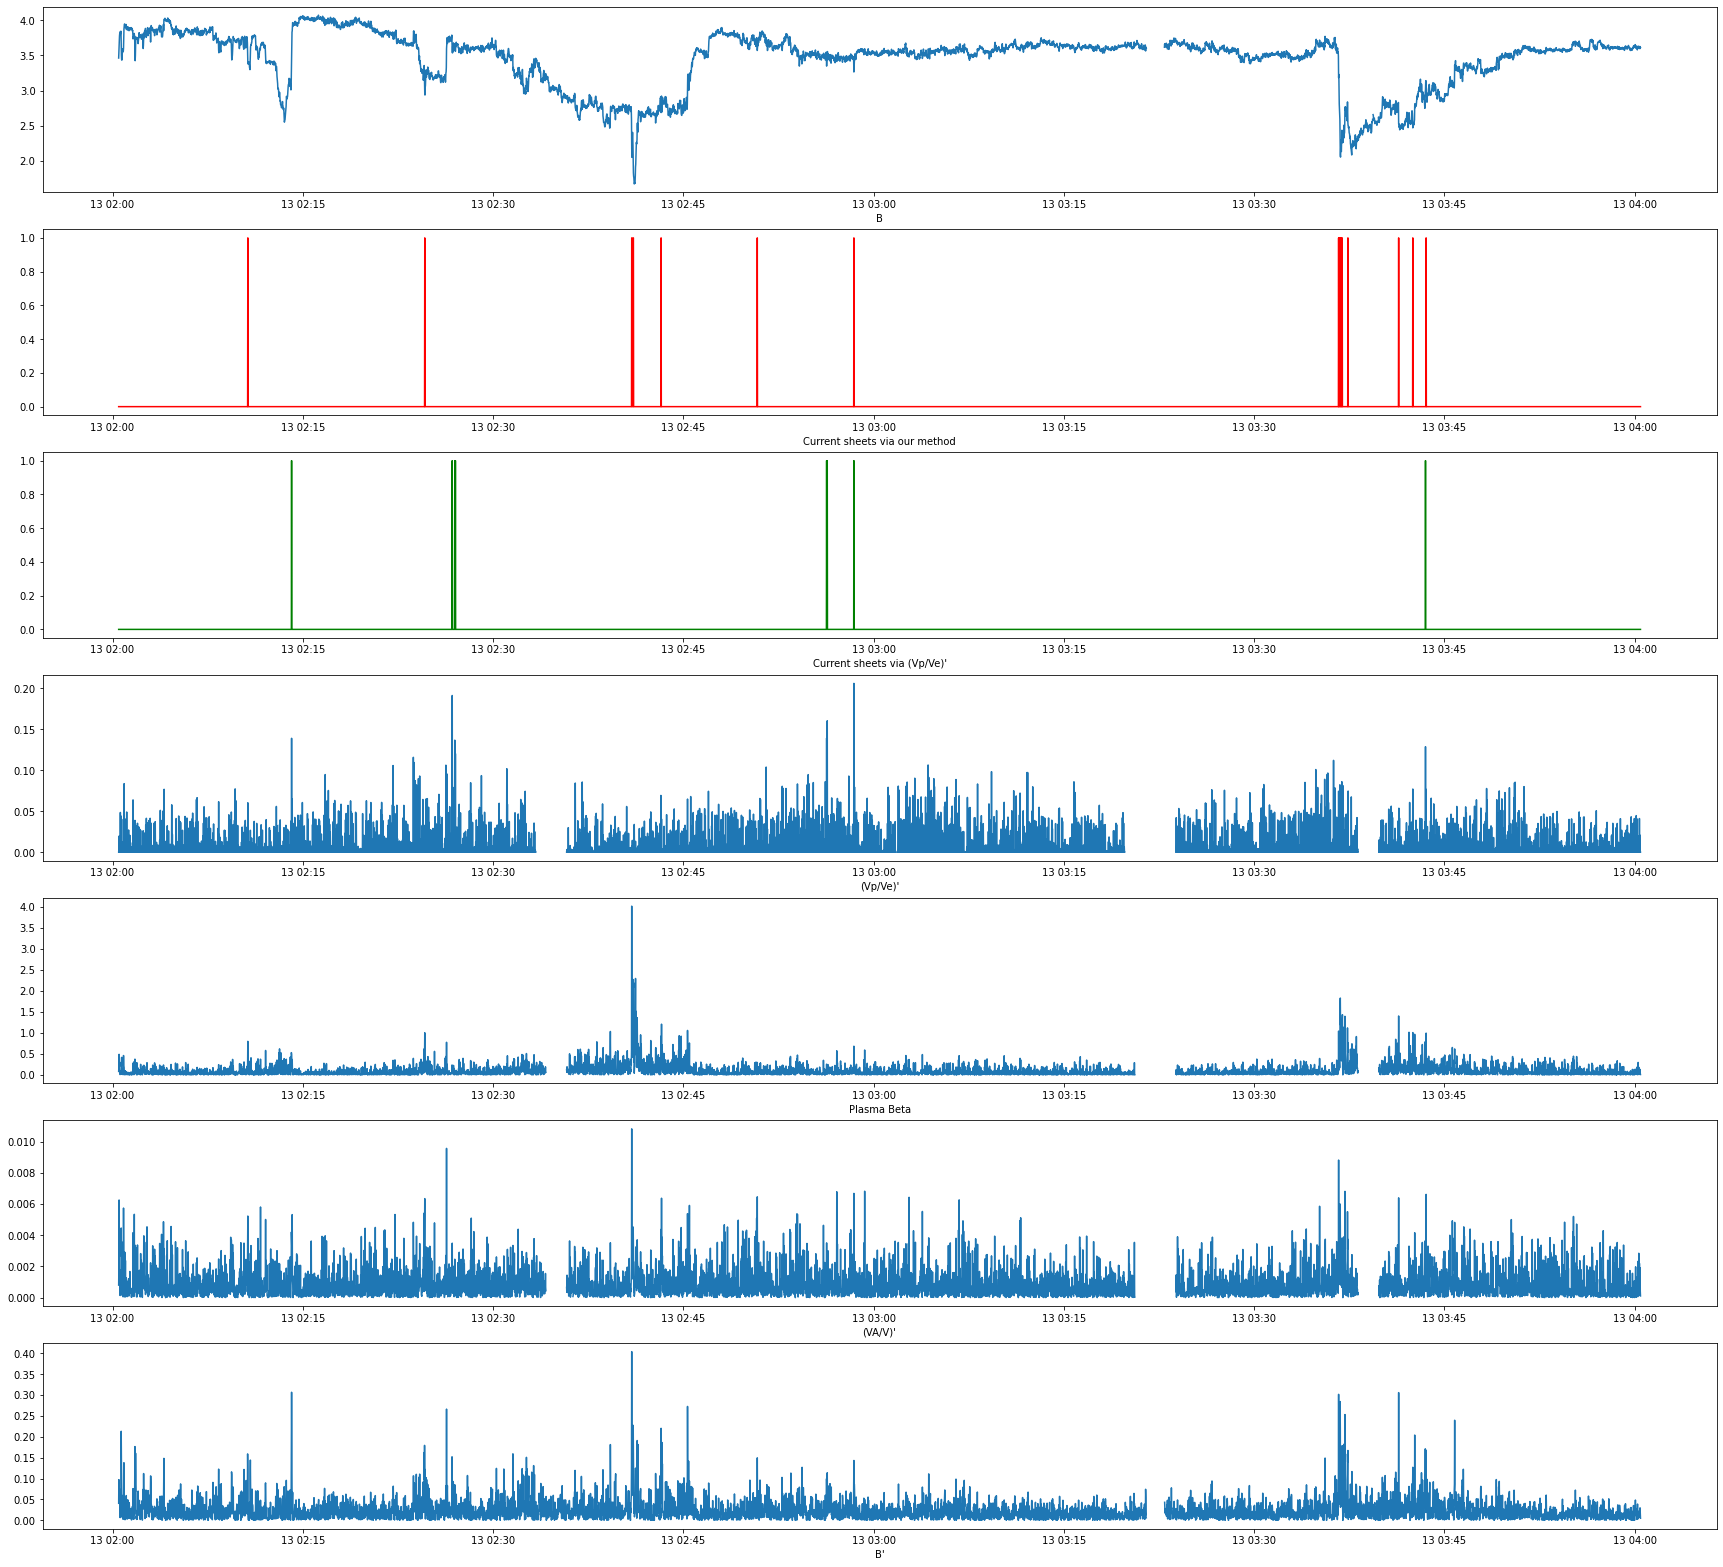

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(30,28))
ax1 = plt.subplot(711)
ax1.plot(df['B_nT'][7200:14400])
ax2 = plt.subplot(712)
ax2.plot(df['current_sheet_v2'][7200:14400], 'r')
ax3 = plt.subplot(713)
ax3.plot(df['current_sheet_buchner'][7200:14400], 'g')
ax4 = plt.subplot(714)
ax4.plot(df['vp/ve_der'].abs()[7200:14400])
ax5 = plt.subplot(715)
ax5.plot(df['Beta_der'].abs()[7200:14400])
ax6 = plt.subplot(716)
ax6.plot(df['VA/V_der'].abs()[7200:14400])
ax7 = plt.subplot(717)
ax7.plot(df['B_der'].abs()[7200:14400])
ax3.set_xlabel("Current sheets via (Vp/Ve)'")
ax2.set_xlabel('Current sheets via our method')
ax1.set_xlabel('B')
ax5.set_xlabel('Plasma Beta')
ax4.set_xlabel("(Vp/Ve)'")
ax6.set_xlabel("(VA/V)'")
ax7.set_xlabel("B'")
plt.show()

In [ ]:
df['current_sheet_v2'] = 0
df.loc[(df['B_der'] <= -0.11) & ((df['VA/V_der'] <= -0.005) | (df['Beta_der'] >= 0.75)), 'current_sheet_v2'] = 1

In [ ]:
df['current_sheet_buchner'] = 0
df.loc[(df['vp/ve_der'].abs() >= 0.12), 'current_sheet_buchner'] = 1

In [ ]:
df['current_sheet_buchner_v2'] = 0
df.loc[(df['B_der'] <= -0.11) & (df['ve/vp_der'].abs() >= 0.025), 'current_sheet_buchner_v2'] = 1

In [ ]:
df = df[29:-2]

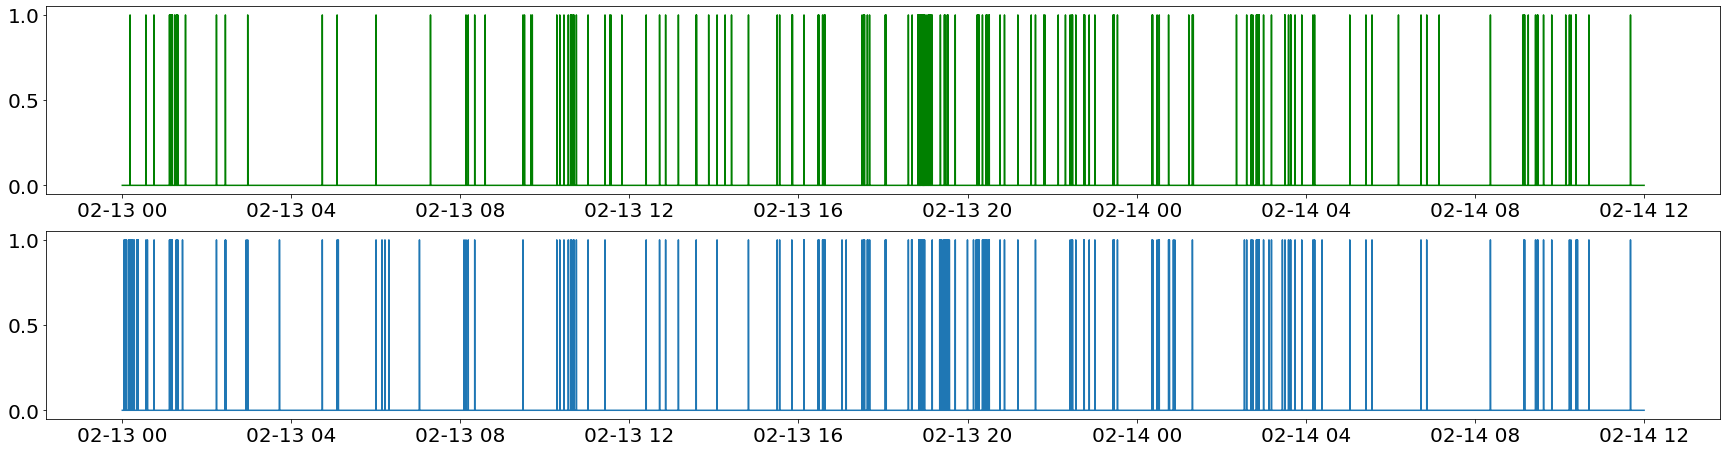

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(30,20))
ax1 = plt.subplot(511)
ax1.plot(df['ve/vp_der'].abs() >= 0.05, 'g')
ax2 = plt.subplot(512)
ax2.plot(df['vp/ve_der'].abs() >= 0.12)
plt.show()

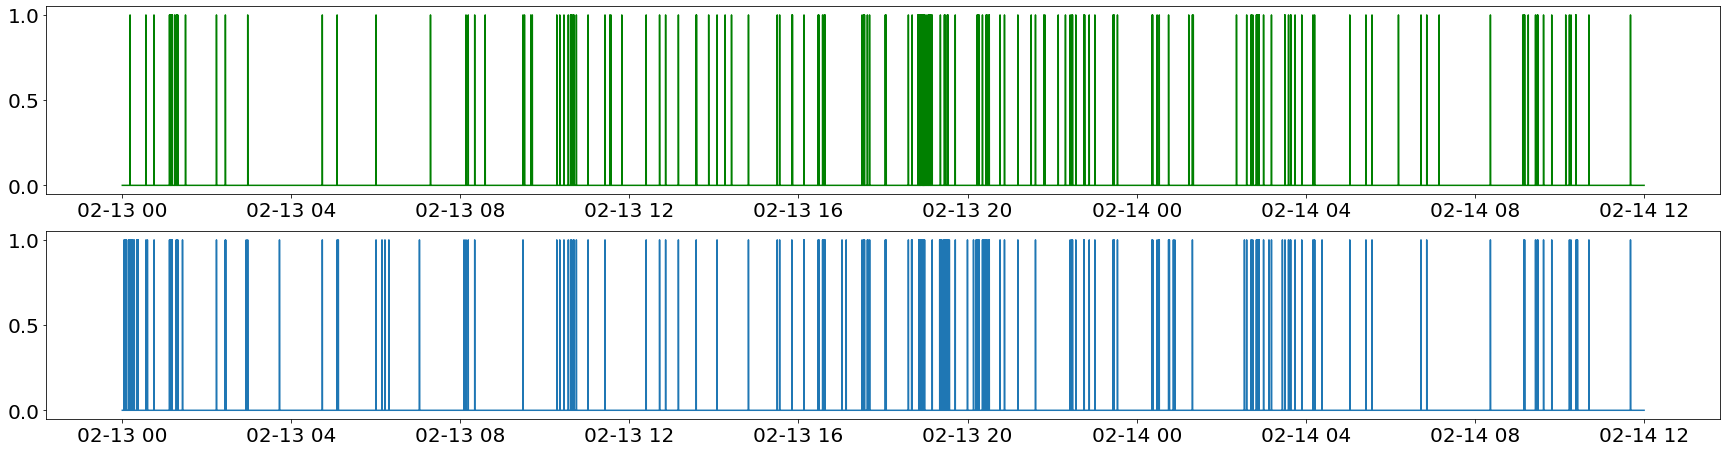

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(30,20))
ax1 = plt.subplot(511)
ax1.plot(df['ve/vp_der'].abs() >= 0.05, 'g')
ax2 = plt.subplot(512)
ax2.plot(df['vp/ve_der'].abs() >= 0.12)
plt.show()